In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, eig
from matplotlib.patches import Ellipse
import os
import glob
import pandas as pd
from datetime import datetime
from scipy.optimize import minimize
from IPython.display import display, Markdown, Math


In [243]:
def display_matrix(matrix, name, precision=4):
    """Display a matrix/vector with a name in a nice format"""
    if matrix.ndim == 1:  # Vector
        df = pd.DataFrame(matrix.reshape(1, -1))
        display(Markdown(f"**{name}:**"))
        display(df.style.format(f"{{:.{precision}f}}"))
    else:  # Matrix
        df = pd.DataFrame(matrix)
        display(Markdown(f"**{name}:**"))
        display(df.style.format(f"{{:.{precision}f}}"))
        
def display_points(points, title="Points"):
    """Display points in a DataFrame"""
    df = pd.DataFrame(points, columns=['x', 'y'])
    df.index = [f"Point {i+1}" for i in range(len(df))]
    display(Markdown(f"**{title}:**"))
    display(df.style.format("{:.4f}"))
    
def display_step(step_name):
    """Display a step header"""
    display(Markdown(f"## {step_name}"))
    
def display_substep(substep_name):
    """Display a substep header"""
    display(Markdown(f"### {substep_name}"))
    
def display_equation(eq_text):
    """Display a LaTeX equation"""
    display(Math(eq_text))
    
def display_parameter(name, value, precision=6):
    """Display a parameter with name and value"""
    display(Markdown(f"**{name}:** {value:.{precision}f}"))

In [244]:
def fit_ellipse_direct_centered(x,y, center_known):
    """
    Direct ellipse-specific fitting method when the center is known.
    Fits Ax'^2 + Bx'y' + Cy'^2 + F = 0 where x'=x-x0, y'=y-y0.
    """
    display_step(f"Direct Ellipse Fitting with Known Center {center_known}")
    
    x0, y0 = center_known
    
    try:
        # Step 1: Shift points
        # x_orig = points[:, 0]
        # y_orig = points[:, 1]
        x_orig = x
        y_orig = y
        x_shifted = x_orig - x0
        y_shifted = y_orig - y0
        
        #display_points(points, "Original points")
        #display_points(np.vstack([x_shifted, y_shifted]).T, "Shifted points (relative to center)")
        
        display_substep("Step 2: Build reduced design matrix D' and scatter matrix S'")
        
        # Build the 4-column design matrix D'
        D_prime = np.vstack([x_shifted**2, x_shifted * y_shifted, y_shifted**2, np.ones_like(x_shifted)]).T
        display_matrix(D_prime[:5], "Design matrix D' (first 5 rows)", 4)
        
        # Form the 4x4 scatter matrix S'
        S_prime = np.dot(D_prime.T, D_prime)
        display_matrix(S_prime, "Scatter matrix S'", 4)
        
        display_substep("Step 3: Build reduced constraint matrix C'")
        
        # Define the 4x4 constraint matrix C'
        C_prime = np.zeros((4, 4))
        C_prime[0, 2] = C_prime[2, 0] = 2  # 2AC term
        C_prime[1, 1] = -1                 # -B^2 term
        display_matrix(C_prime, "Constraint matrix C'", 1)
        
        display_substep("Step 4: Solve the eigenvalue problem (S')^-1 * C'")
        
        try:
            S_prime_inv = np.linalg.inv(S_prime)
            M = S_prime_inv @ C_prime
            
            E, V = np.linalg.eig(M)
            # Ensure eigenvalues/vectors are real (should be if inputs are real)
            E = np.real_if_close(E)
            V = np.real_if_close(V)
            
            display_matrix(E, "Eigenvalues μ of (S')^-1 * C'", 6)
            display_matrix(V, "Eigenvectors a' of (S')^-1 * C' (columns)", 6)
            
            # Find the index of the unique positive eigenvalue
            positive_eigenvalue_indices = np.where(E > 1e-8)[0] # Check for positivity with tolerance
            
            if len(positive_eigenvalue_indices) != 1:
                display(Markdown(f"**Error:** Expected 1 positive eigenvalue, found {len(positive_eigenvalue_indices)}. Trying largest magnitude."))
                # Fallback: use largest magnitude eigenvalue if positive one is not unique/found
                n = np.argmax(np.abs(E))
            else:
                 n = positive_eigenvalue_indices[0]
                 display(Markdown(f"Selected positive eigenvalue μ = {E[n]:.6f} at index {n}"))

            # Get the corresponding eigenvector a' = [A, B, C, F]
            a_prime = V[:, n]
            display_matrix(a_prime, "Selected eigenvector a' = [A, B, C, F]", 6)

        except np.linalg.LinAlgError:
            display(Markdown("**Error:** Failed to solve eigenvalue problem. Matrix S' may be singular."))
            return None, None, None, None
            
        display_substep("Step 5: Extract geometric parameters")
        
        A, B_coeff, C_coeff, F_val = a_prime
        
        # Standard form uses B/2 for the 2x2 matrix Q
        B_half = B_coeff / 2.0 
        
        # Form the 2x2 matrix Q
        Q = np.array([[A, B_half], [B_half, C_coeff]])
        display_matrix(Q, "Matrix Q = [[A, B/2], [B/2, C]]", 6)
        
        # Check the discriminant for the quadratic part
        discriminant_quadratic = B_coeff**2 - 4 * A * C_coeff
        display_parameter("Discriminant (B² - 4AC)", discriminant_quadratic)
        if discriminant_quadratic >= -1e-8: # Allow tolerance
             display(Markdown("**Warning:** Quadratic part is not strictly elliptic."))
             # Might still proceed if F has the right sign

        # Find eigenvalues (lambda_1, lambda_2) and eigenvectors of Q
        eigvals_Q, eigvecs_Q = np.linalg.eigh(Q) # Use eigh for symmetric matrix
        display_matrix(eigvals_Q, "Eigenvalues λ₁, λ₂ of Q", 6)
        display_matrix(eigvecs_Q, "Eigenvectors of Q (columns)", 6)

        # --- Sign Handling ---
        # Convention: Ax^2 + Bxy + Cy^2 + F = 0. 
        # For ellipse points, F should have opposite sign to eigenvalues.
        # If F >= 0 and eigenvalues > 0, flip signs of A, B, C, F.
        if F_val >= 0 and np.all(eigvals_Q > 0):
             display(Markdown("**Note:** F >= 0 and Q is positive definite. Flipping signs of A, B, C, F for standard ellipse form."))
             A, B_coeff, C_coeff, F_val = -A, -B_coeff, -C_coeff, -F_val
             eigvals_Q = -eigvals_Q # Eigenvalues also flip sign

        if F_val >= -1e-10: # Check F is negative (or close to zero) with tolerance
             display(Markdown(f"**Warning:** Constant term F ({F_val:.4f}) is not negative. Result might be degenerate (point/empty)."))
             # Can return None or attempt calculation, depends on desired robustness
             # return center_known, None, None, None # Option to fail early

        # Calculate semi-axes lengths
        try:
            # Ensure denominators are positive before sqrt
            denom1 = -F_val / eigvals_Q[0]
            denom2 = -F_val / eigvals_Q[1]
            
            if denom1 < 0 or denom2 < 0:
                 display(Markdown("**Error:** Cannot calculate axes, division by zero or negative value under sqrt."))
                 return center_known, None, None, None

            semi_axis_1 = np.sqrt(denom1)
            semi_axis_2 = np.sqrt(denom2)
            semi_axes = np.array([semi_axis_1, semi_axis_2])
            display_matrix(semi_axes, "Calculated semi-axes lengths", 6)
        except (ValueError, ZeroDivisionError) as e:
             display(Markdown(f"**Error:** Could not calculate semi-axes: {e}"))
             return center_known, None, None, None

        # Determine rotation angle from eigenvectors of Q
        # Angle is from x-axis to the axis corresponding to eigvals_Q[0]
        angle = np.arctan2(eigvecs_Q[1, 0], eigvecs_Q[0, 0]) 
        
        # Ensure major axis (a) >= minor axis (b)
        if semi_axes[0] < semi_axes[1]:
            semi_axes = semi_axes[::-1] # Swap axes lengths
            # Adjust angle by 90 degrees as eigenvectors are orthogonal
            angle = angle + np.pi/2 
            display(Markdown("**Note:** Swapping axes (a <-> b) and adjusting angle by 90 deg."))

        # Normalize angle to be within (-pi, pi] or [0, 2pi) if desired
        angle = (angle + np.pi) % (2 * np.pi) - np.pi 

        display_parameter("Final semi-major axis a", semi_axes[0])
        display_parameter("Final semi-minor axis b", semi_axes[1])
        display_parameter("Final rotation angle (radians)", angle)
        display_parameter("Final rotation angle (degrees)", angle * 180 / np.pi)

        # Visualize
        display_substep("Step 6: Visualization")
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.scatter(x_orig, y_orig, c='black', s=60, label='Data points')
        ax.plot(x0, y0, 'mx', markersize=12, label='Known Center')
        
        # Plot fitted ellipse
        t = np.linspace(0, 2*np.pi, 200)
        a_axis, b_axis = semi_axes
        x_ellipse = x0 + a_axis * np.cos(t) * np.cos(angle) - b_axis * np.sin(t) * np.sin(angle)
        y_ellipse = y0 + a_axis * np.cos(t) * np.sin(angle) + b_axis * np.sin(t) * np.cos(angle)
        ax.plot(x_ellipse, y_ellipse, 'm-', linewidth=2, label='Fitted Ellipse (Centered)')
        
        ax.set_aspect('equal')
        ax.grid(True)
        ax.legend()
        ax.set_title(f'Direct Ellipse Fit with Known Center ({x0:.2f}, {y0:.2f})')
        plt.show()

        return a_axis, b_axis, angle # Return algebraic params too if needed

    except Exception as e:
        display(Markdown(f"**ERROR during centered ellipse fitting:** {str(e)}"))
        import traceback
        traceback.print_exc() # Print full traceback for debugging
        return None, None, None, None

In [245]:
def fit_centered_ellipse(x, y, center):
    # # Translate data to center
    # x_ = x - center[0]
    # y_ = y - center[1]

    # # Build design matrix for conic: [x'^2, x'y', y'^2]
    # D = np.vstack([x_**2, x_ * y_, y_**2]).T

    # # Solve the least squares problem D * [A, B, C] = -1
    # # We assume the ellipse equation is Ax^2 + Bxy + Cy^2 + F = 0, with F = -1
    # # This prevents trivial zero solution
    # b = -np.ones_like(x)
    # params, _, _, _ = np.linalg.lstsq(D, b, rcond=None)

    # A, B, C = params
    # M = np.array([[A, B/2],
    #               [B/2, C]])

    # # Eigen decomposition
    # eigvals, eigvecs = np.linalg.eigh(M)

    # # Sort eigenvalues and corresponding eigenvectors
    # order = np.argsort(eigvals)
    # eigvals = eigvals[order]
    # eigvecs = eigvecs[:, order]

    # # Semi-axes lengths (F = -1 in the conic equation Ax^2 + Bxy + Cy^2 + F = 0)
    # F = -1
    # a_sq_inv = eigvals[0]  # smaller eigenvalue → major axis
    # b_sq_inv = eigvals[1]  # larger eigenvalue → minor axis

    # if a_sq_inv <= 0 or b_sq_inv <= 0:
    #     raise ValueError("Invalid ellipse parameters: not a real ellipse.")

    # a = np.sqrt(-F / a_sq_inv)  # semi-major axis
    # b = np.sqrt(-F / b_sq_inv)  # semi-minor axis

    # # Orientation (angle of major axis w.r.t. x-axis)
    # major_axis_vector = eigvecs[:, 0]
    # angle = np.arctan2(major_axis_vector[1], major_axis_vector[0])  # in radians

    # return a, b, np.degrees(angle)
    x = np.asarray(x)
    y = np.asarray(y)
    xc, yc = center

    # Shift the data to the common center
    x_shifted = x - xc
    y_shifted = y - yc

    # Objective: minimize the sum of squared errors between points and the ellipse
    def objective(params):
        a, b, theta_deg = params
        theta = np.radians(theta_deg)
        
        # Parametric ellipse equation: x = a*cos(t), y = b*sin(t)
        # Rotate the coordinates of the input points back (inverse rotation)
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        x_rot = x_shifted * cos_t + y_shifted * sin_t
        y_rot = -x_shifted * sin_t + y_shifted * cos_t
        
        # Ellipse implicit equation error: (x/a)^2 + (y/b)^2 ≈ 1
        ellipse_eq = (x_rot / a)**2 + (y_rot / b)**2
        return np.sum((ellipse_eq - 1.0)**2)

    # Initial guesses: a, b, theta
    a0 = (np.max(x_shifted) - np.min(x_shifted)) / 2
    b0 = (np.max(y_shifted) - np.min(y_shifted)) / 2
    initial_guess = [a0, b0, 0.0]  # a, b, angle in degrees

    # Constraints: a > 0, b > 0
    bounds = [(1e-3, None), (1e-3, None), (-180, 180)]

    result = minimize(objective, initial_guess, bounds=bounds)

    if not result.success:
        raise ValueError("Ellipse fitting failed.")

    a_opt, b_opt, angle_opt = result.x
    return a_opt, b_opt, angle_opt

In [246]:
def fit_ellipse(x, y):
    D = np.vstack([x**2, x*y, y**2, x, y, np.ones_like(x)]).T
    S = np.dot(D.T, D)
    C = np.zeros((6, 6))
    C[0, 2] = C[2, 0] = 2
    C[1, 1] = -1
    E, V = np.linalg.eig(np.linalg.inv(S).dot(C))
    n = np.argmax(np.abs(E))
    a = V[:, n]
    return a

In [247]:
def ellipse_params(a):
    b, c, d, f, g, a_ = a[1]/2, a[2], a[3]/2, a[4]/2, a[5], a[0]
    num = b**2 - a_*c
    x0 = (c*d - b*f) / num
    y0 = (a_*f - b*d) / num

    up = 2*(a_*f**2 + c*d**2 + g*b**2 - 2*b*d*f - a_*c*g)
    down1 = (b**2 - a_*c)*((c - a_)*np.sqrt(1 + 4*b**2/((a_-c)**2)) - (c + a_))
    down2 = (b**2 - a_*c)*((a_ - c)*np.sqrt(1 + 4*b**2/((a_-c)**2)) - (c + a_))

    axis_a = np.sqrt(abs(up / down1))
    axis_b = np.sqrt(abs(up / down2))

    theta = 0.5 * np.arctan(2*b / (a_ - c))
    theta_degrees = np.degrees(theta)

    # Print the values of A, B, C, D, E, F
    print(f"A (coefficient for x^2): {a_}")
    print(f"B (coefficient for xy): {b}")
    print(f"C (coefficient for y^2): {c}")
    print(f"D (coefficient for x): {d}")
    print(f"E (coefficient for y): {f}")
    print(f"F (constant): {g}")
    

    print(f"Center (x0, y0): ({x0}, {y0})")
    print(f"Semi-major axis (a): {axis_a}")
    print(f"Semi-minor axis (b): {axis_b}")
    print(f"Rotation angle (theta in radians): {theta}")
    print(f"Rotation angle (theta in degrees): {theta_degrees}")
    
    return (x0, y0, axis_a, axis_b, theta)

In [248]:
def get_minimum_volume_enclosing_ellipse(P, tolerance=1e-5):
    N, d = P.shape
    Q = np.vstack([P.T, np.ones(N)])
    err = tolerance + 1.0
    u = np.ones(N) / N

    while err > tolerance:
        X = Q @ np.diag(u) @ Q.T
        M = np.einsum('ij,jk,ki->i', Q.T, inv(X), Q)
        j = np.argmax(M)
        max_M = M[j]
        step_size = (max_M - d - 1) / ((d + 1) * (max_M - 1))
        new_u = (1 - step_size) * u
        new_u[j] += step_size
        err = np.linalg.norm(new_u - u)
        u = new_u

    center = P.T @ u
    cov_matrix = (P.T - center[:, np.newaxis]) @ np.diag(u) @ (P.T - center[:, np.newaxis]).T
    A = inv(cov_matrix) / d

    return center, A

In [249]:
def plot_fit_ellipse(x0, y0, a, b, angle, ax):
    theta = np.linspace(0, 2*np.pi, 300)
    ellipse_x = a * np.cos(theta)
    ellipse_y = b * np.sin(theta)
    
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle), np.cos(angle)]])
    
    ellipse = np.dot(R, np.array([ellipse_x, ellipse_y]))
    
    ax.plot(x0 + ellipse[0, :], y0 + ellipse[1, :], 'r-', label='Fitted Ellipse', linewidth=2)


In [250]:
def plot_bound_ellipse(center, A, ax, edgecolor='red'):
    vals, vecs = eig(inv(A))
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    width, height = 2 * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                      edgecolor=edgecolor, fc='None', lw=2)
    ax.add_patch(ellipse)

In [251]:
csv_files = glob.glob("output_contour_*.csv")
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)
df.to_csv("All_data_set.csv", index=False)
print(df.head())

df = pd.read_csv("All_data_set.csv")
print(df.columns)

      X     Y
0  1148  1116
1  1148  1118
2  1059  1053
3  1145  1119
4  1146  1119
Index(['X', 'Y'], dtype='object')


In [252]:
points = df[['X', 'Y']].values

In [253]:
x = df.iloc[:, 0].values
y = df.iloc[:, 1].values
coeffs = fit_ellipse(x, y)
x0, y0, a_axis, b_axis, angle = ellipse_params(coeffs)

A (coefficient for x^2): -4.433573065739571e-07
B (coefficient for xy): 6.763245280411391e-08
C (coefficient for y^2): -5.582312931627639e-07
D (coefficient for x): 0.0005166415744605585
E (coefficient for y): 0.0004228336028637675
F (constant): -0.999999108585795
Center (x0, y0): (1304.9582291472896, 915.5544215592595)
Semi-major axis (a): 385.7733745758615
Semi-minor axis (b): 322.5248360632915
Rotation angle (theta in radians): 0.4333683485063705
Rotation angle (theta in degrees): 24.830177343969623


In [254]:
#center, A = get_minimum_volume_enclosing_ellipse(points)
center = x0, y0
print(f"Ellipse Center: ({center[0]:.4f}, {center[1]:.4f})")

Ellipse Center: (1304.9582, 915.5544)


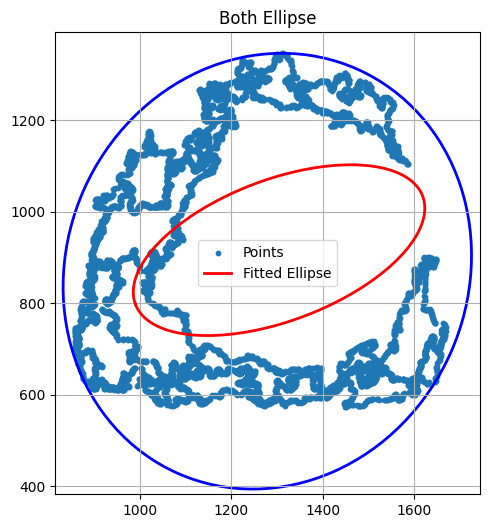

In [266]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, label='Points')
plot_bound_ellipse(center, A, ax, edgecolor='blue')
plot_fit_ellipse(x0, y0, a_axis, b_axis, angle, ax)
ax.set_aspect('equal')
ax.set_title('Both Ellipse')
plt.legend()
plt.grid(True)
plt.show()

In [256]:
current_dir = os.getcwd()
print(f"Checking in: {current_dir}")

Checking in: /Users/vish/Exp


In [257]:
# ref_file = 'output_contour_0.csv'
# if not os.path.exists(ref_file):
#     raise FileNotFoundError(f"{ref_file} not found in the current directory.")

# ref_mtime = os.path.getmtime(ref_file)

In [258]:
# all_files = glob.glob('output_contour*.csv')
# for file in all_files:
#     if os.path.getmtime(file) != ref_mtime:
#         print(file)
#         os.remove(file)


Processing output_contour_12.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,24635.8857,-31461.5830,40178.4299,1.0000
1,24635.8857,-31775.4995,40984.2122,1.0000


...

**Final semi-major axis a:** 460.354785

**Final semi-minor axis b:** 308.079007

**Final rotation angle (radians):** -2.700160

**Final rotation angle (degrees):** -154.707793

### Step 6: Visualization

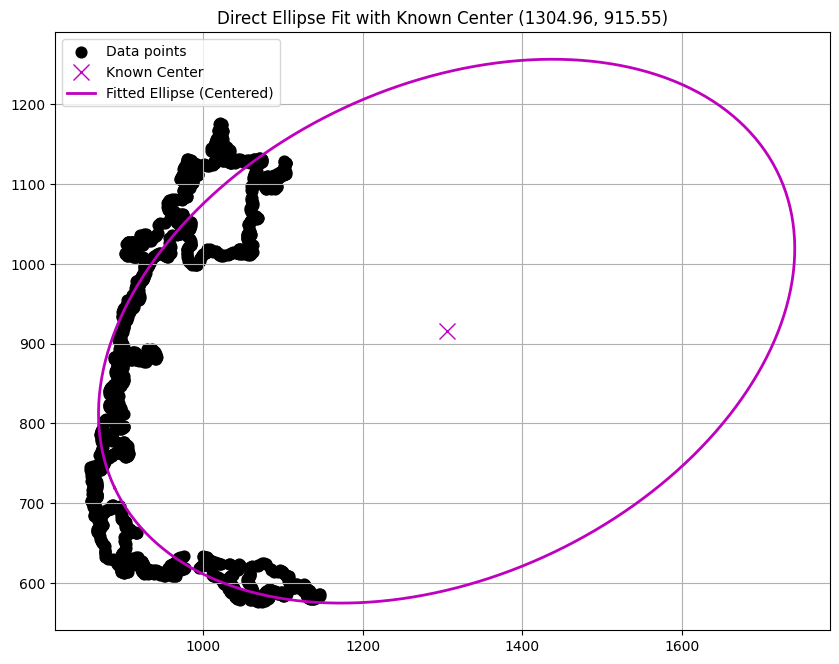

Ellipse:Axes=(460.35, 308.08), Angle=-2.70°

Processing output_contour_14.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,72877.4455,-26306.2358,9495.6408,1.0000


...

**Final semi-major axis a:** 379.558107

**Final semi-minor axis b:** 175.418629

**Final rotation angle (radians):** -2.079423

**Final rotation angle (degrees):** -119.142138

### Step 6: Visualization

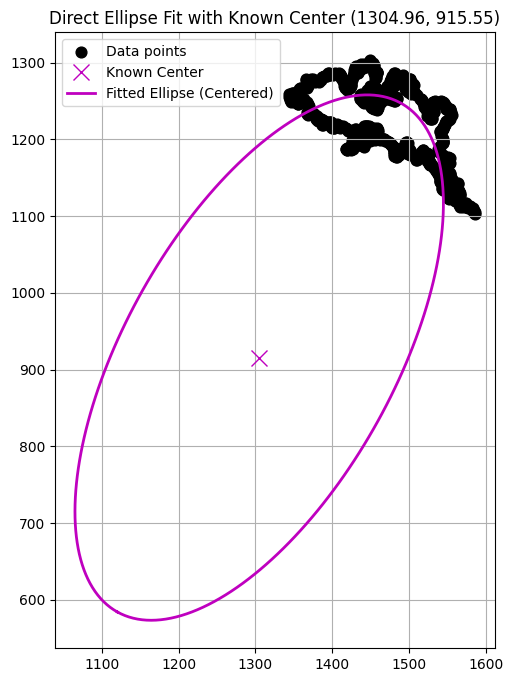

Ellipse:Axes=(379.56, 175.42), Angle=-2.08°

Processing output_contour_16.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,128851.0103,108604.3994,91539.1780,1.0000
1,131013.7596,108426.1880,89732.8515,1.0000
2,131738.6761,108725.7424,89732.8515,1.0000
3,132465.5926,108661.3386,89134.7426,1.0000
4,134658.3419,109557.0018,89134.7426,1.0000


...

**Final semi-major axis a:** 404.312402

**Final semi-minor axis b:** 259.794649

**Final rotation angle (radians):** -2.674915

**Final rotation angle (degrees):** -153.261330

### Step 6: Visualization

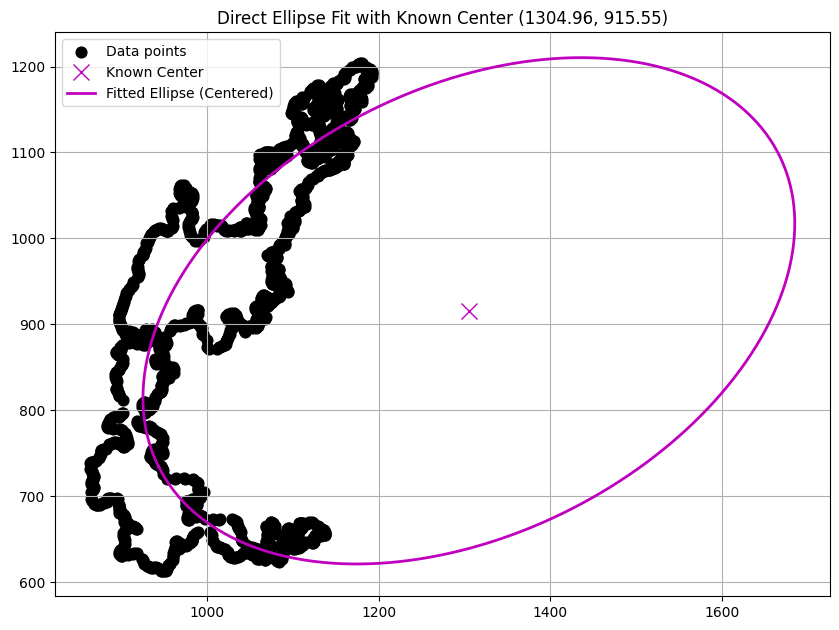

Ellipse:Axes=(404.31, 259.79), Angle=-2.67°

Processing output_contour_8.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,781.6626,9297.6327,110592.4433,1.0000
1,838.5790,9601.2289,109928.3345,1.0000
2,1222.0778,11590.5554,109928.3345,1.0000
3,1760.4930,13617.7288,105335.5726,1.0000
4,1845.4095,13942.2832,105335.5726,1.0000


...

**Final semi-major axis a:** 307.890957

**Final semi-minor axis b:** 272.855111

**Final rotation angle (radians):** -0.929862

**Final rotation angle (degrees):** -53.277179

### Step 6: Visualization

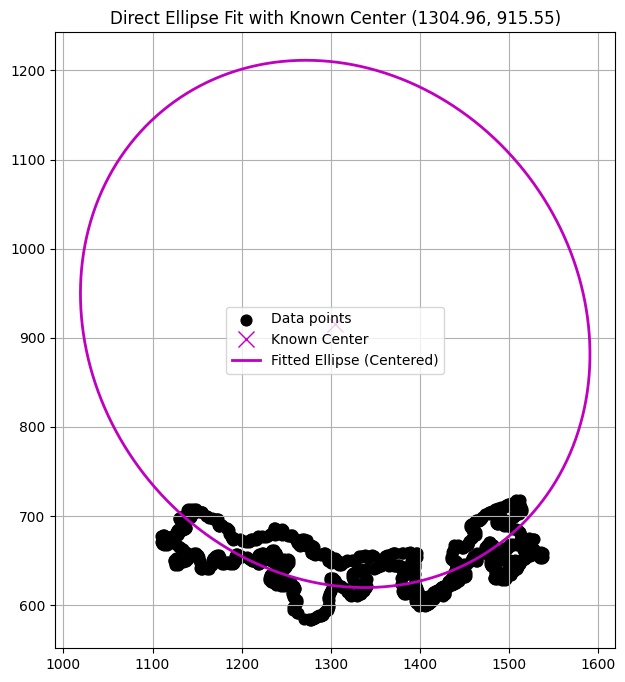

Ellipse:Axes=(307.89, 272.86), Angle=-0.93°

Processing output_contour_9.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,59028.7011,67434.1308,77036.4569,1.0000
1,59515.6176,67467.7269,76482.3481,1.0000
2,61483.2834,68573.9446,76482.3481,1.0000
3,61980.1999,68601.5408,75930.2392,1.0000
4,63482.9492,69428.2041,75930.2392,1.0000


...

**Final semi-major axis a:** 378.044363

**Final semi-minor axis b:** 161.352267

**Final rotation angle (radians):** -2.653439

**Final rotation angle (degrees):** -152.030834

### Step 6: Visualization

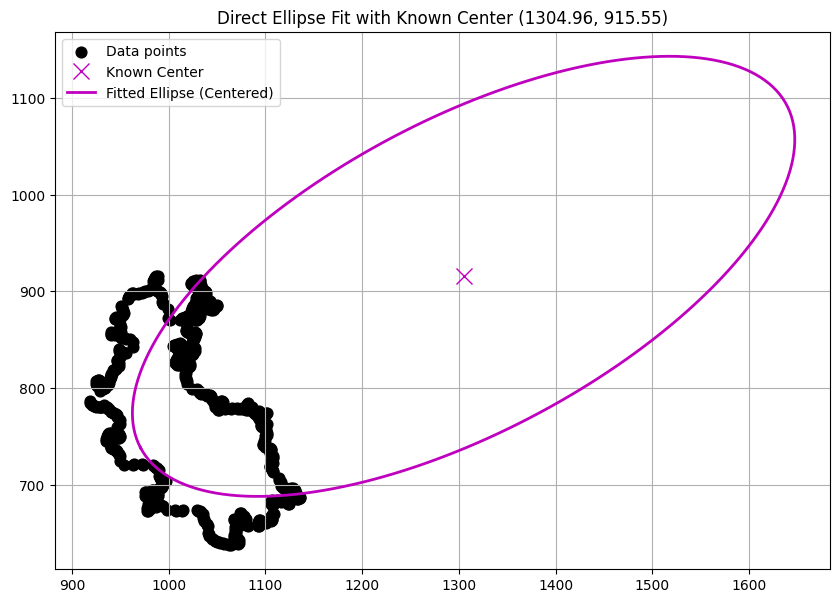

Ellipse:Axes=(378.04, 161.35), Angle=-2.65°

Processing output_contour_2.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,37232.8782,44873.2894,54081.5590,1.0000


...

**Final semi-major axis a:** 474.029693

**Final semi-minor axis b:** 322.397559

**Final rotation angle (radians):** 3.129061

**Final rotation angle (degrees):** 179.281993

### Step 6: Visualization

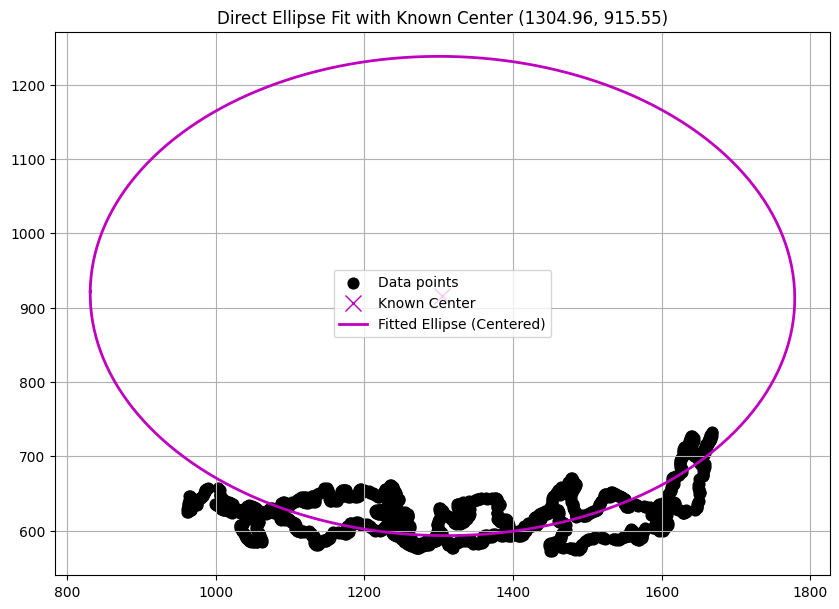

Ellipse:Axes=(474.03, 322.40), Angle=3.13°

Processing output_contour_0.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,34209.5465,50781.0996,75380.1304,1.0000


...

**Final semi-major axis a:** 331.145314

**Final semi-minor axis b:** 36.972193

**Final rotation angle (radians):** -0.900020

**Final rotation angle (degrees):** -51.567335

### Step 6: Visualization

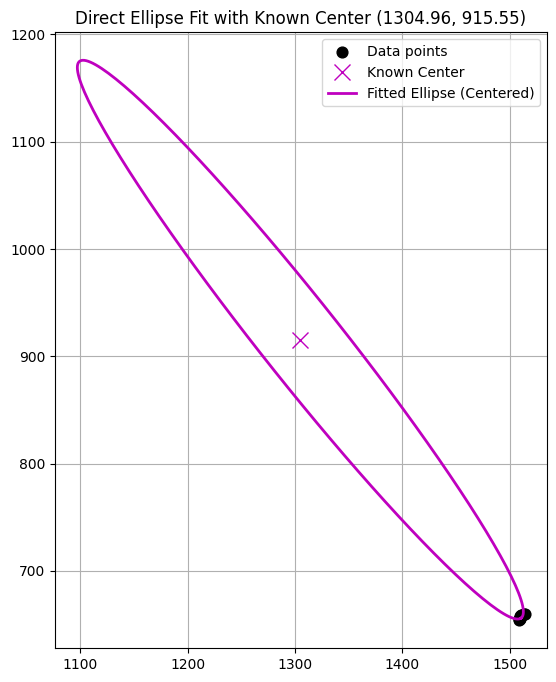

Ellipse:Axes=(331.15, 36.97), Angle=-0.90°

Processing output_contour_5.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,3838.8222,16825.0311,73741.8039,1.0000


...

**Final semi-major axis a:** 377.571518

**Final semi-minor axis b:** 206.488544

**Final rotation angle (radians):** 2.534169

**Final rotation angle (degrees):** 145.197197

### Step 6: Visualization

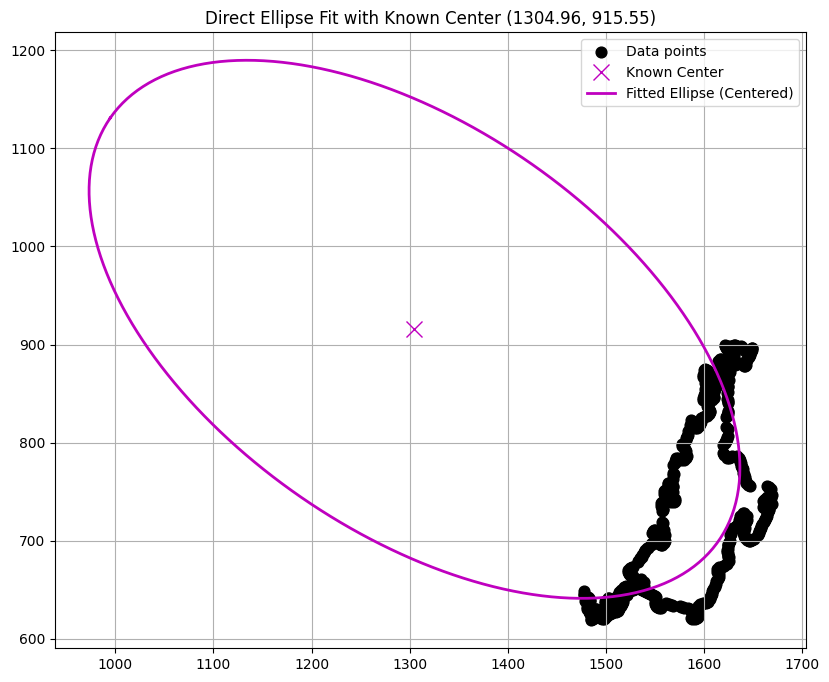

Ellipse:Axes=(377.57, 206.49), Angle=2.53°

Processing output_contour_20.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center (np.float64(1304.9582291472896), np.float64(915.5544215592595))

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,10395.4805,-27370.2358,72063.0286,1.0000
1,10807.3134,-28115.0434,73140.8109,1.0000
2,11016.2299,-28385.4890,73140.8109,1.0000
3,11227.1463,-28761.8928,73682.7021,1.0000
4,11227.1463,-28867.8510,74226.5932,1.0000


...

**Final semi-major axis a:** 393.392048

**Final semi-minor axis b:** 167.952720

**Final rotation angle (radians):** -1.419035

**Final rotation angle (degrees):** -81.304696

### Step 6: Visualization

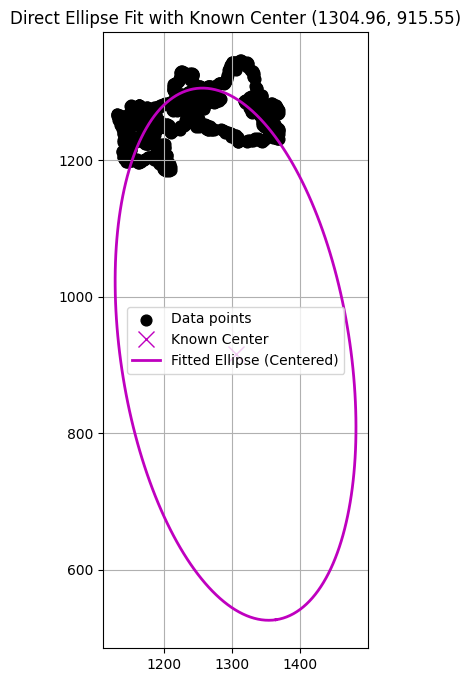

Ellipse:Axes=(393.39, 167.95), Angle=-1.42°


In [259]:
remaining_files = glob.glob('output_contour*.csv')
for file in remaining_files:
    print(f"\nProcessing {file}")
    
    try:
        df = pd.read_csv(file)
    except Exception as e:
        print(f"Could not read {file}: {e}")
        continue
    print(df.columns)

    x = df.iloc[:, 0].values
    y = df.iloc[:, 1].values

    try:
        # coeffs = fit_ellipse(x, y)
        # x0, y0, a_axis, b_axis, angle = ellipse_params(coeffs)
        #a_axis, b_axis, angle = fit_centered_ellipse(x, y, center)
        a_axis, b_axis, angle = fit_ellipse_direct_centered(x,y,center)
    except ValueError as e:
        print(f"Skipping {file}: {e}")
        continue

    print(f"Ellipse:Axes=({a_axis:.2f}, {b_axis:.2f}), Angle={angle:.2f}°")

    # # Plot
    # theta = np.linspace(0, 2*np.pi, 300)
    # ellipse_x = center[0] + a_axis * np.cos(theta) * np.cos(np.radians(angle)) - b_axis * np.sin(theta) * np.sin(np.radians(angle))
    # ellipse_y = center[1] + a_axis * np.cos(theta) * np.sin(np.radians(angle)) + b_axis * np.sin(theta) * np.cos(np.radians(angle))

    # plt.figure(figsize=(6, 6))
    # plt.plot(x, y, 'bo', label='Points', markersize=3)
    # plt.plot(ellipse_x, ellipse_y, 'r-', label='Fitted Ellipse', linewidth=2)
    # plt.gca().set_aspect('equal')
    # plt.title(f"Centered Ellipse Fit for {file}")
    # plt.xlabel('X')
    # plt.ylabel('Y')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,25387.7244,36434.3224,52287.4688,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 451.538244

**Final semi-minor axis b:** 274.597382

**Final rotation angle (radians):** 3.066976

**Final rotation angle (degrees):** 175.724780

### Step 6: Visualization

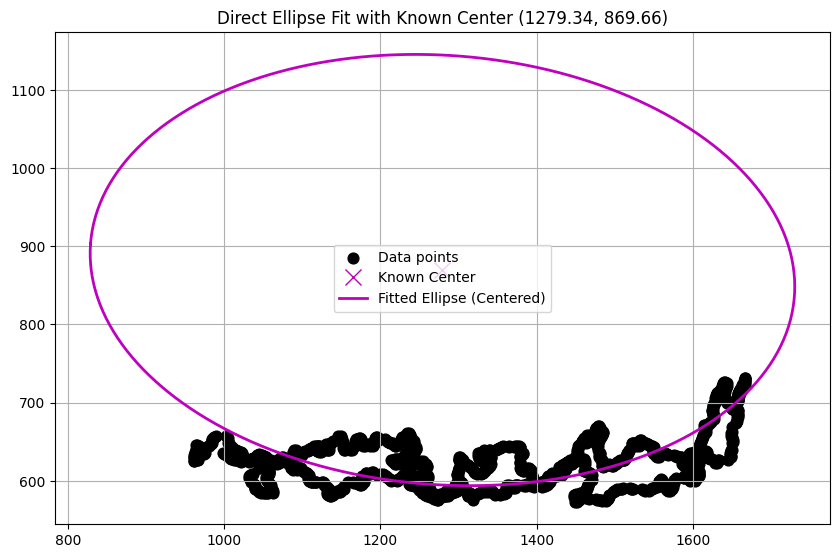

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,44662.5912,62061.6699,86238.8581,1.0000
1,45086.2617,62142.9991,85652.5290,1.0000
2,45511.9322,62435.6637,85652.5290,1.0000
3,45939.6027,62513.9929,85068.2000,1.0000
4,48107.9553,63972.3156,85068.2000,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 416.672129

**Final semi-minor axis b:** 313.221659

**Final rotation angle (radians):** -2.906080

**Final rotation angle (degrees):** -166.506137

### Step 6: Visualization

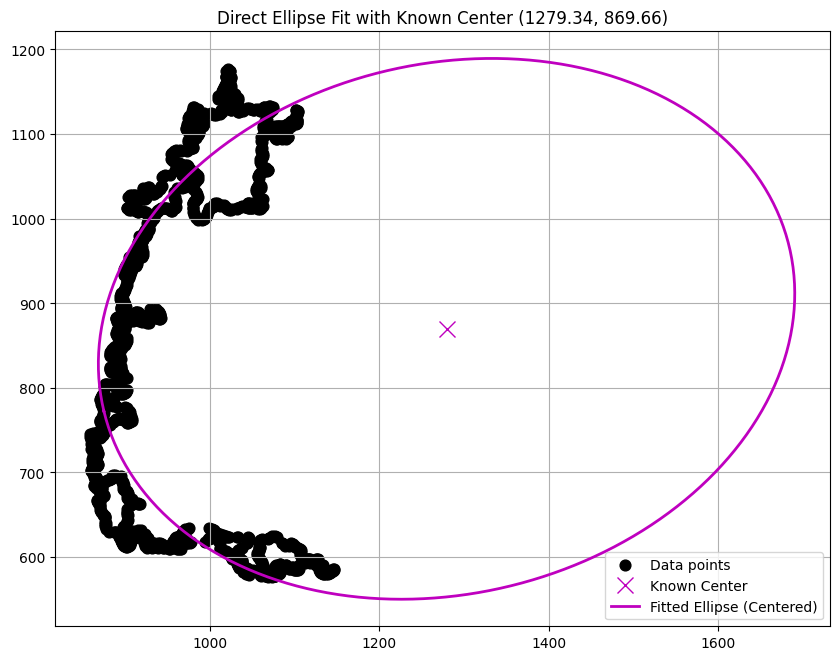

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,18045.9615,-33494.5442,62168.1750,1.0000
1,17778.2910,-33245.2087,62168.1750,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** inf

**Final semi-minor axis b:** 244.335258

**Final rotation angle (radians):** 1.570796

**Final rotation angle (degrees):** 90.000000

### Step 6: Visualization

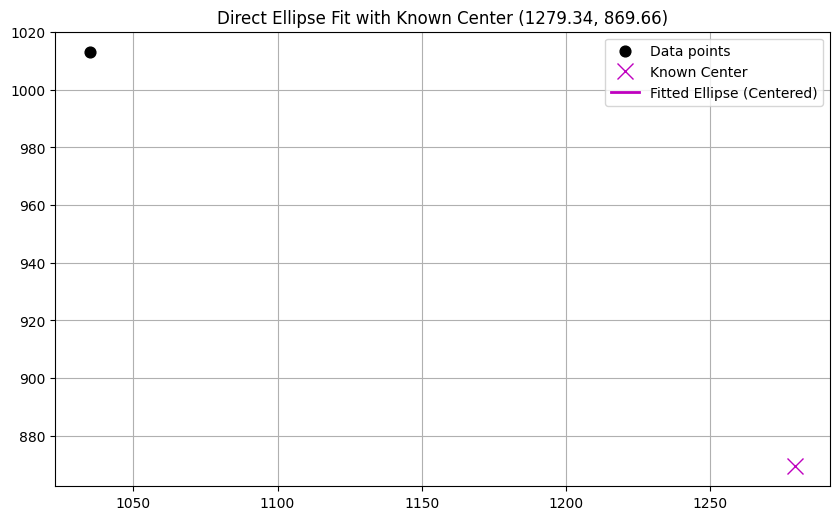

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,141628.2263,-7276.6178,373.8603,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 357.985529

**Final semi-minor axis b:** 279.315559

**Final rotation angle (radians):** -2.799375

**Final rotation angle (degrees):** -160.392377

### Step 6: Visualization

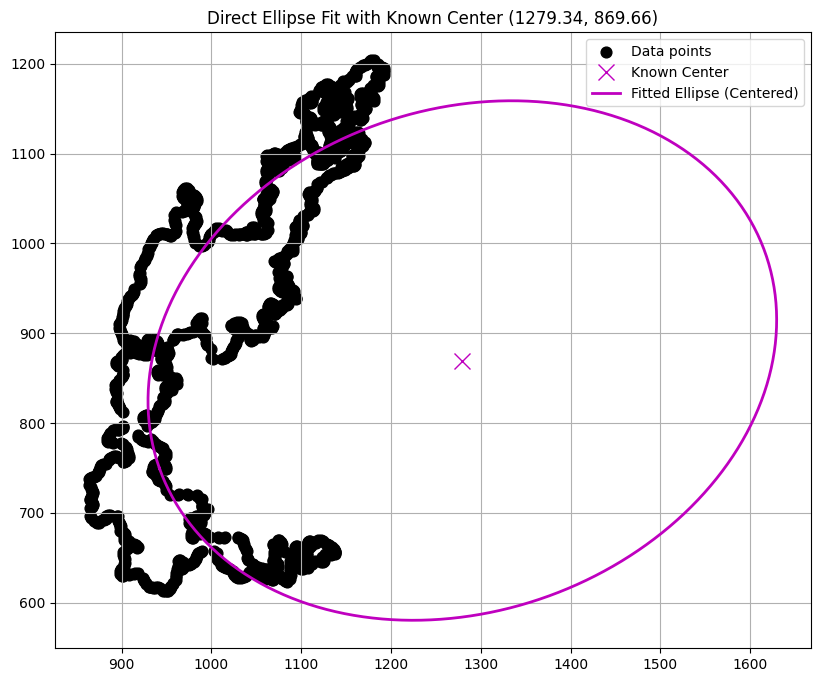

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,94043.2641,71555.7607,54445.4400,1.0000
1,93430.9346,71628.0900,54913.1110,1.0000
2,93430.9346,71933.7548,55382.7819,1.0000
3,91605.9462,72135.7426,56803.7947,1.0000
4,91605.9462,72438.4073,57281.4656,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 432.038465

**Final semi-minor axis b:** 186.276360

**Final rotation angle (radians):** -2.080030

**Final rotation angle (degrees):** -119.176923

### Step 6: Visualization

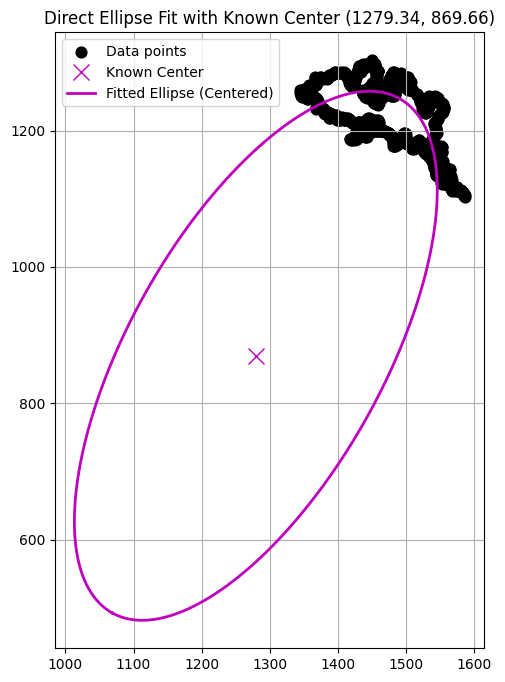

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,2055.2856,-19010.6815,175842.2336,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 436.285414

**Final semi-minor axis b:** 174.772882

**Final rotation angle (radians):** -1.515308

**Final rotation angle (degrees):** -86.820740

### Step 6: Visualization

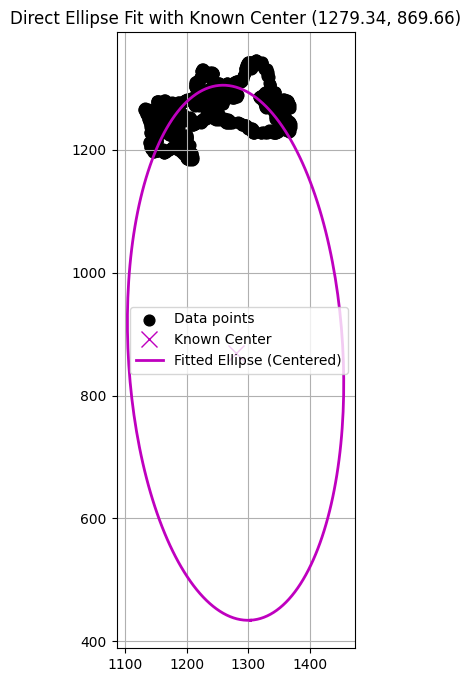

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,42297.9862,-51552.8566,62832.7083,1.0000
1,42297.9862,-51347.1919,62332.3792,1.0000
2,42710.3157,-51390.1917,61834.0501,1.0000
3,42710.3157,-50976.8622,60843.3920,1.0000
4,41887.6567,-50074.2036,59860.7339,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 378.708651

**Final semi-minor axis b:** 208.560704

**Final rotation angle (radians):** 2.767707

**Final rotation angle (degrees):** 158.577956

### Step 6: Visualization

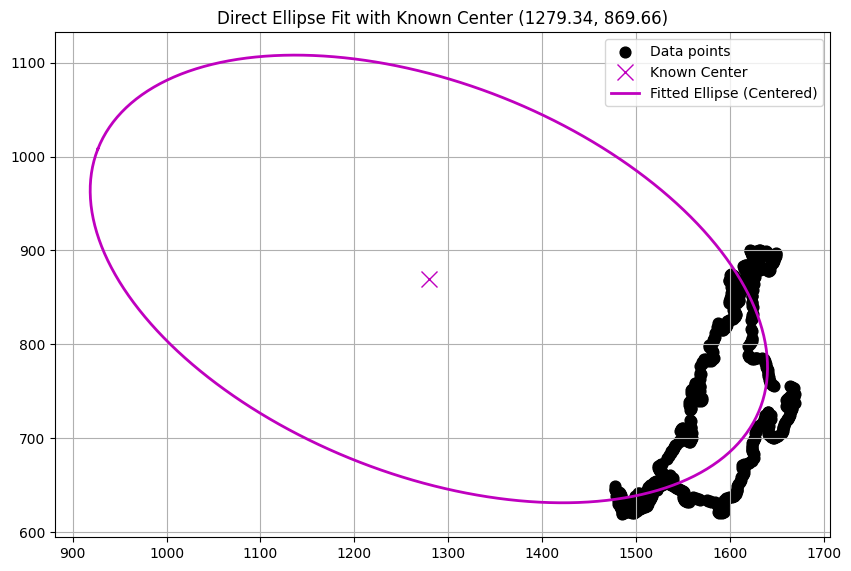

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,29699.4411,32685.8862,35972.6352,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 314.954301

**Final semi-minor axis b:** 37.229394

**Final rotation angle (radians):** 2.398584

**Final rotation angle (degrees):** 137.428752

### Step 6: Visualization

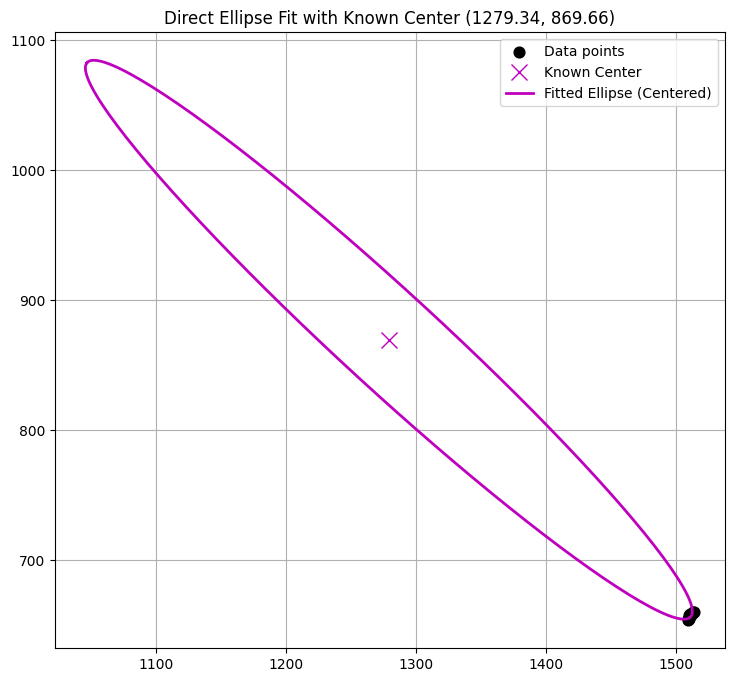

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,1320.2510,8199.5790,50924.4816,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 315.609699

**Final semi-minor axis b:** 167.771419

**Final rotation angle (radians):** -2.514611

**Final rotation angle (degrees):** -144.076578

### Step 6: Visualization

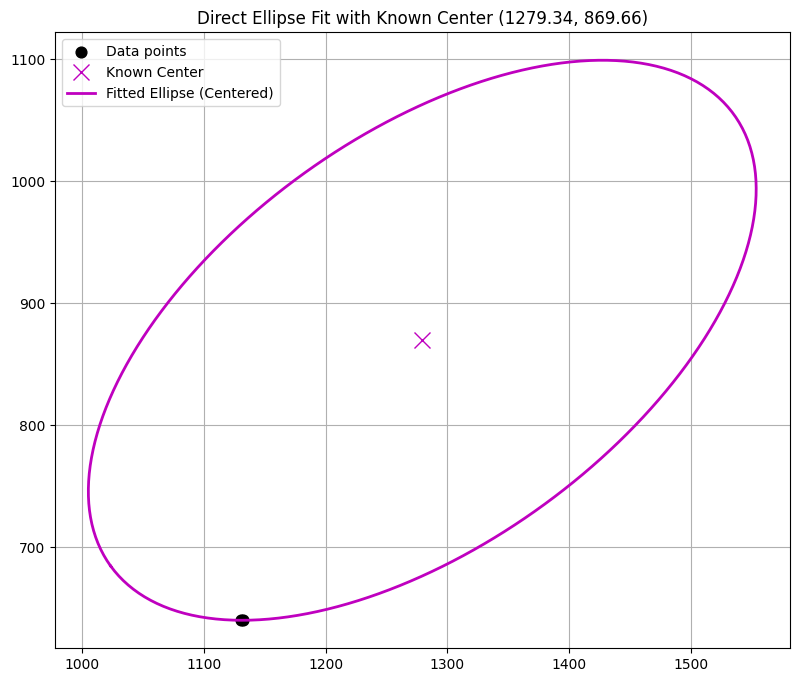

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,1626.9330,9545.9250,56010.1013,1.0000
1,1792.2741,9934.5835,55067.4432,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 291.531943

**Final semi-minor axis b:** 225.923511

**Final rotation angle (radians):** 2.522232

**Final rotation angle (degrees):** 144.513266

### Step 6: Visualization

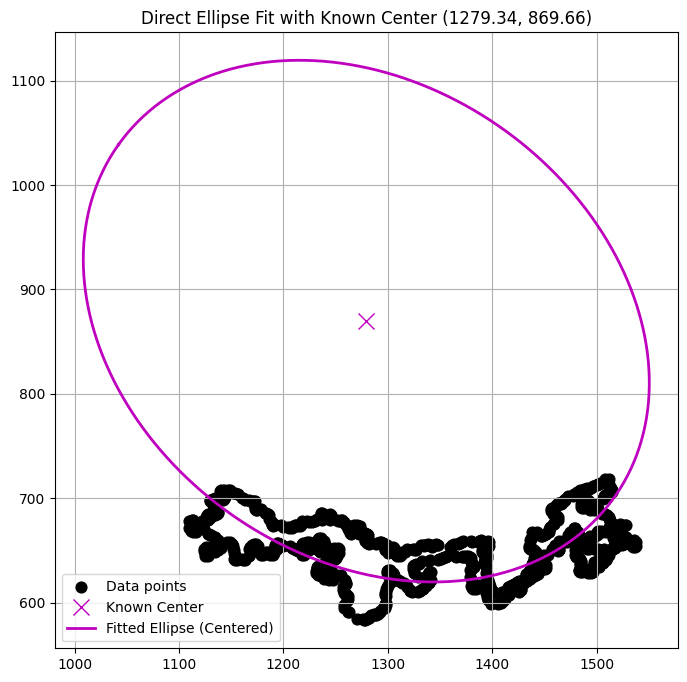

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,47234.6143,50348.8711,53668.4560,1.0000
1,47670.2848,50362.2003,53206.1269,1.0000
2,49432.9669,51284.8585,53206.1269,1.0000
3,49878.6374,51292.1878,52745.7979,1.0000
4,51227.6489,51981.1814,52745.7979,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 335.492648

**Final semi-minor axis b:** 154.417156

**Final rotation angle (radians):** -2.781674

**Final rotation angle (degrees):** -159.378191

### Step 6: Visualization

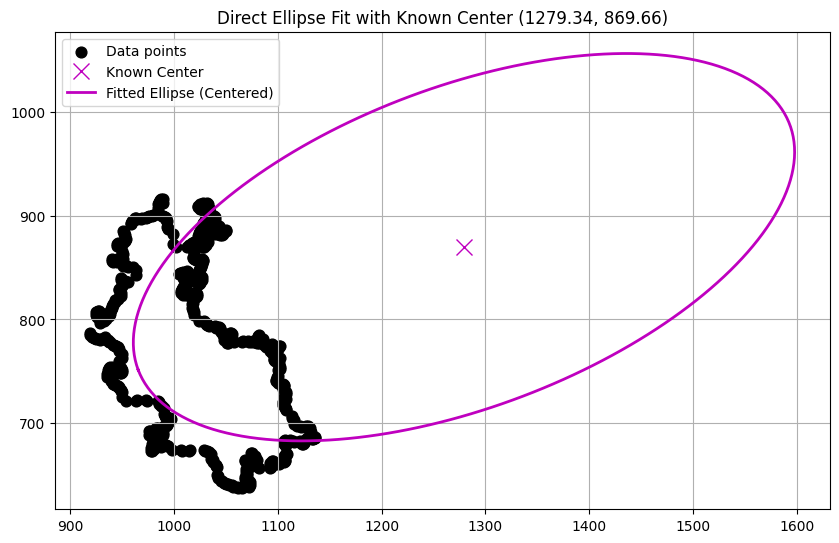

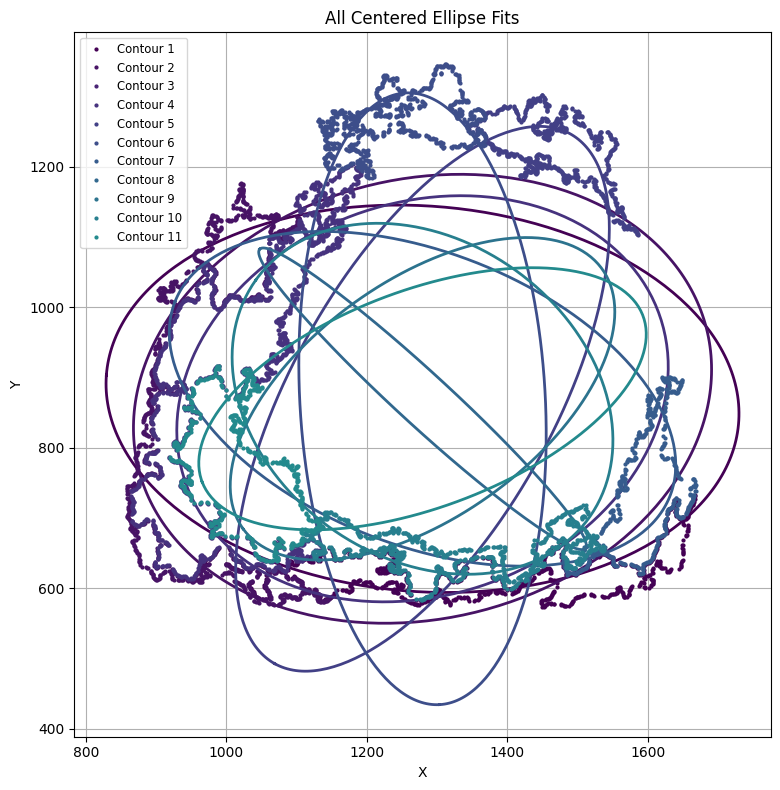

In [265]:
# ---------------------------------------------
# Plot all fitted ellipses and data in one plot
# ---------------------------------------------

# Rewind the loop to plot everything together
all_data = []
all_ellipses = []

# Sort files to maintain consistent color order
remaining_files = sorted(glob.glob('output_contour*.csv'))
colors = plt.cm.viridis(np.linspace(0, 1, len(remaining_files)))

for i, file in enumerate(remaining_files):
    try:
        df = pd.read_csv(file)
        x = df.iloc[:, 0].values
        y = df.iloc[:, 1].values
        a_axis, b_axis, angle = fit_ellipse_direct_centered(x, y, center)
        # coeffs = fit_ellipse(x, y)
        # x0, y0, a_axis, b_axis, angle = ellipse_params(coeffs)
        # center = x0,y0

        all_data.append((x, y))
        all_ellipses.append((a_axis, b_axis, angle))

    except Exception as e:
        print(f"Skipping {file}: {e}")
        continue

# Now make one global plot
plt.figure(figsize=(8, 8))

for i, ((x, y), (a_axis, b_axis, angle)) in enumerate(zip(all_data, all_ellipses)):
    color = colors[i]
    plt.plot(x, y, 'o', markersize=2, label=f'Contour {i+1}', color=color)

    theta = np.linspace(0, 2*np.pi, 300)
    angle_rad = angle
    ellipse_x = center[0] + a_axis * np.cos(theta) * np.cos(angle_rad) - b_axis * np.sin(theta) * np.sin(angle_rad)
    ellipse_y = center[1] + a_axis * np.cos(theta) * np.sin(angle_rad) + b_axis * np.sin(theta) * np.cos(angle_rad)
    plt.plot(ellipse_x, ellipse_y, '-', linewidth=2, color=color)

plt.gca().set_aspect('equal')
plt.title("All Centered Ellipse Fits")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()


In [261]:
center, A = get_minimum_volume_enclosing_ellipse(points)
print(f"Ellipse Center: ({center[0]:.4f}, {center[1]:.4f})")

/var/folders/4t/y461_gl57qb87nxcmq188fym0000gp/T/ipykernel_3947/1040988113.py:8: RuntimeWarning: divide by zero encountered in matmul
  X = Q @ np.diag(u) @ Q.T
/var/folders/4t/y461_gl57qb87nxcmq188fym0000gp/T/ipykernel_3947/1040988113.py:8: RuntimeWarning: overflow encountered in matmul
  X = Q @ np.diag(u) @ Q.T
/var/folders/4t/y461_gl57qb87nxcmq188fym0000gp/T/ipykernel_3947/1040988113.py:8: RuntimeWarning: invalid value encountered in matmul
  X = Q @ np.diag(u) @ Q.T


Ellipse Center: (1279.3353, 869.6645)


/var/folders/4t/y461_gl57qb87nxcmq188fym0000gp/T/ipykernel_3947/1040988113.py:19: RuntimeWarning: divide by zero encountered in matmul
  cov_matrix = (P.T - center[:, np.newaxis]) @ np.diag(u) @ (P.T - center[:, np.newaxis]).T
/var/folders/4t/y461_gl57qb87nxcmq188fym0000gp/T/ipykernel_3947/1040988113.py:19: RuntimeWarning: overflow encountered in matmul
  cov_matrix = (P.T - center[:, np.newaxis]) @ np.diag(u) @ (P.T - center[:, np.newaxis]).T
/var/folders/4t/y461_gl57qb87nxcmq188fym0000gp/T/ipykernel_3947/1040988113.py:19: RuntimeWarning: invalid value encountered in matmul
  cov_matrix = (P.T - center[:, np.newaxis]) @ np.diag(u) @ (P.T - center[:, np.newaxis]).T



Processing output_contour_12.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,17248.9499,-32352.5320,60681.1622,1.0000
1,17248.9499,-32615.2025,61670.5040,1.0000


...

**Final semi-major axis a:** 416.672129

**Final semi-minor axis b:** 313.221659

**Final rotation angle (radians):** -2.906080

**Final rotation angle (degrees):** -166.506137

### Step 6: Visualization

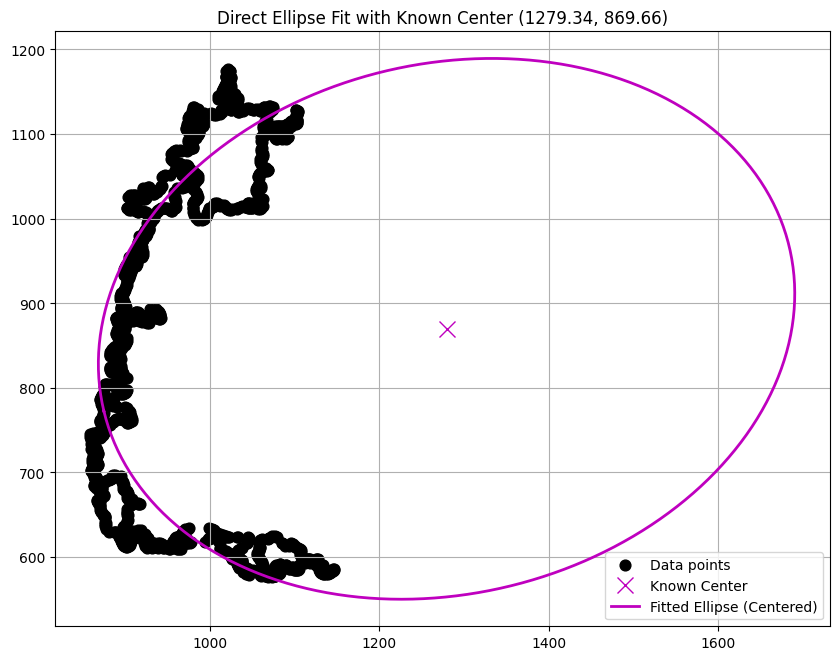

Ellipse:Axes=(416.67, 313.22), Angle=-2.91°

Processing output_contour_14.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,59699.7182,-35021.9082,20545.0560,1.0000


...

**Final semi-major axis a:** inf

**Final semi-minor axis b:** 244.335258

**Final rotation angle (radians):** 1.570796

**Final rotation angle (degrees):** 90.000000

### Step 6: Visualization

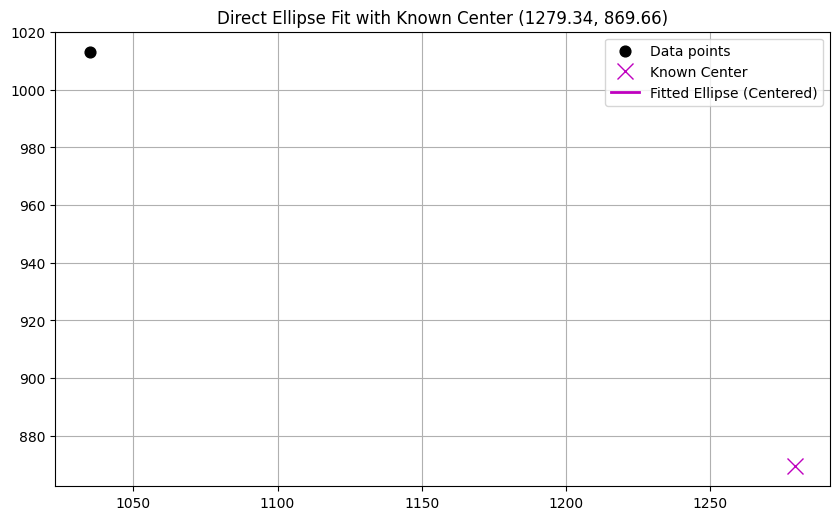

Ellipse:Axes=(inf, 244.34), Angle=1.57°

Processing output_contour_15.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,141628.2263,-7276.6178,373.8603,1.0000


...

**Final semi-major axis a:** 432.038465

**Final semi-minor axis b:** 186.276360

**Final rotation angle (radians):** -2.080030

**Final rotation angle (degrees):** -119.176923

### Step 6: Visualization

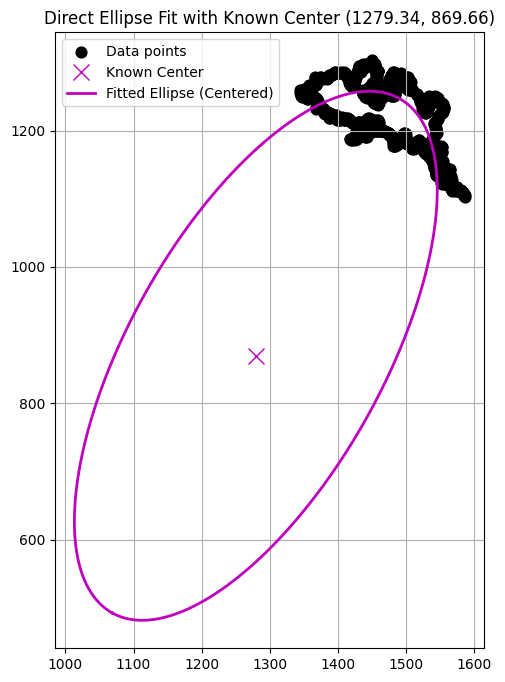

Ellipse:Axes=(432.04, 186.28), Angle=-2.08°

Processing output_contour_16.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,111112.3941,85555.3384,65876.6826,1.0000
1,113121.4056,85316.3262,64345.6954,1.0000
2,113795.0762,85569.9907,64345.6954,1.0000
3,114470.7467,85485.3200,63839.3664,1.0000
4,116509.7582,86243.3136,63839.3664,1.0000


...

**Final semi-major axis a:** 357.985529

**Final semi-minor axis b:** 279.315559

**Final rotation angle (radians):** -2.799375

**Final rotation angle (degrees):** -160.392377

### Step 6: Visualization

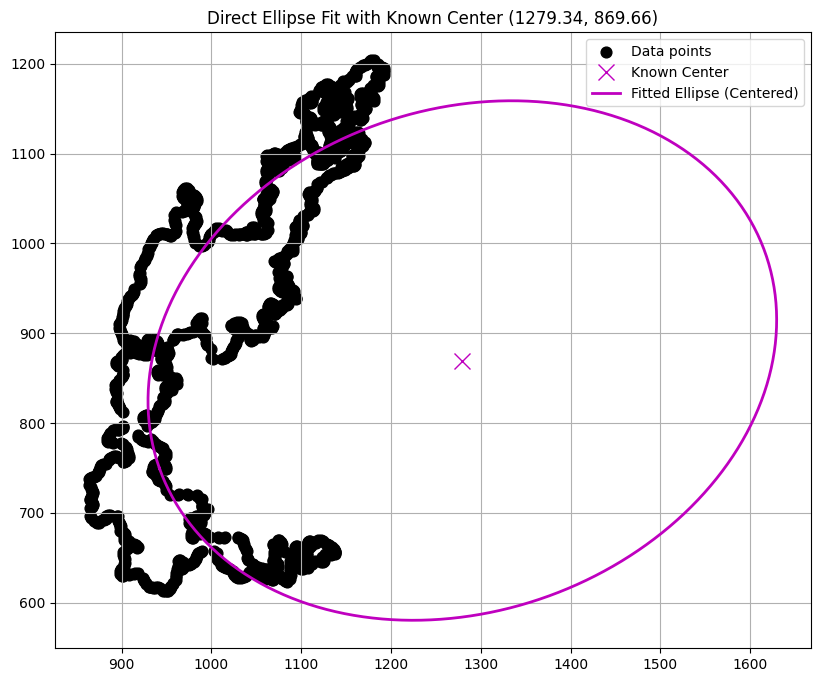

Ellipse:Axes=(357.99, 279.32), Angle=-2.80°

Processing output_contour_8.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,5.4534,669.4356,82176.5546,1.0000
1,11.1239,952.7649,81604.2256,1.0000
2,87.1470,2666.7521,81604.2256,1.0000
3,266.8406,4552.0570,77653.9221,1.0000
4,300.5112,4830.7215,77653.9221,1.0000


...

**Final semi-major axis a:** 291.531943

**Final semi-minor axis b:** 225.923511

**Final rotation angle (radians):** 2.522232

**Final rotation angle (degrees):** 144.513266

### Step 6: Visualization

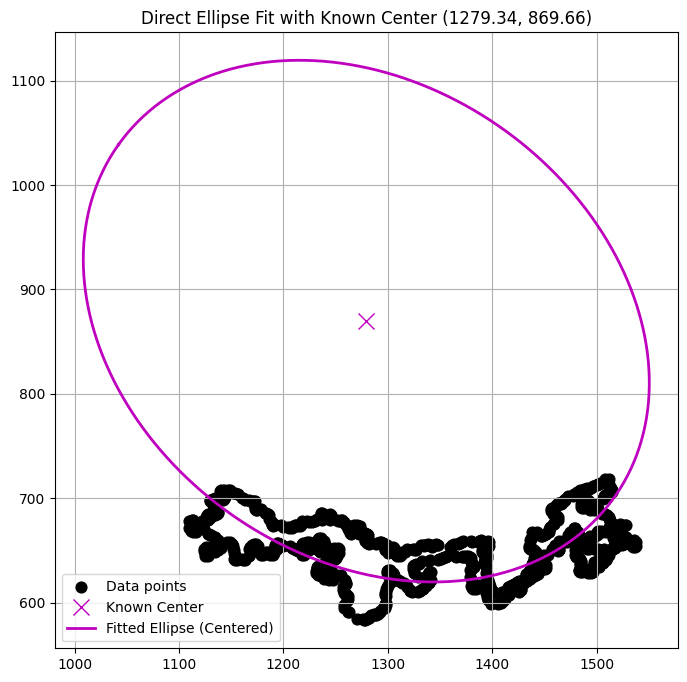

Ellipse:Axes=(291.53, 225.92), Angle=2.52°

Processing output_contour_9.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,47234.6143,50348.8711,53668.4560,1.0000
1,47670.2848,50362.2003,53206.1269,1.0000
2,49432.9669,51284.8585,53206.1269,1.0000
3,49878.6374,51292.1878,52745.7979,1.0000
4,51227.6489,51981.1814,52745.7979,1.0000


...

**Final semi-major axis a:** 335.492648

**Final semi-minor axis b:** 154.417156

**Final rotation angle (radians):** -2.781674

**Final rotation angle (degrees):** -159.378191

### Step 6: Visualization

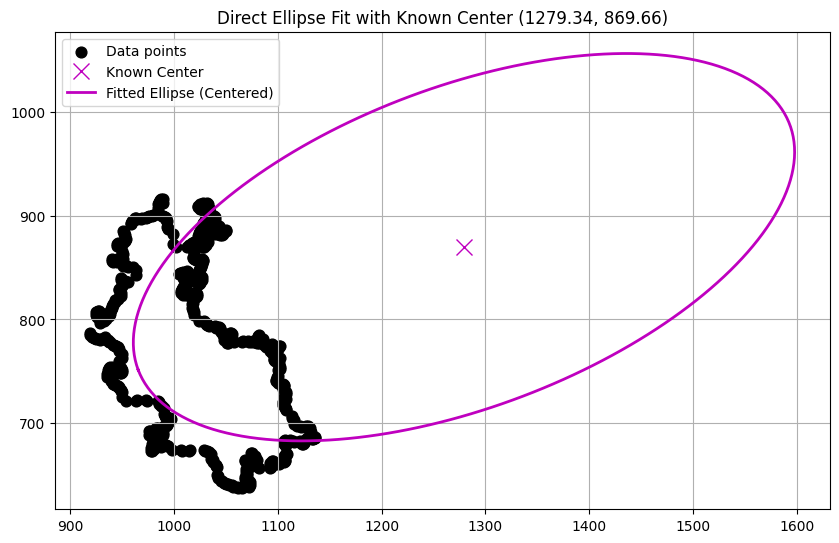

Ellipse:Axes=(335.49, 154.42), Angle=-2.78°

Processing output_contour_2.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,28001.0885,31235.5578,34843.6480,1.0000


...

**Final semi-major axis a:** 451.538244

**Final semi-minor axis b:** 274.597382

**Final rotation angle (radians):** 3.066976

**Final rotation angle (degrees):** 175.724780

### Step 6: Visualization

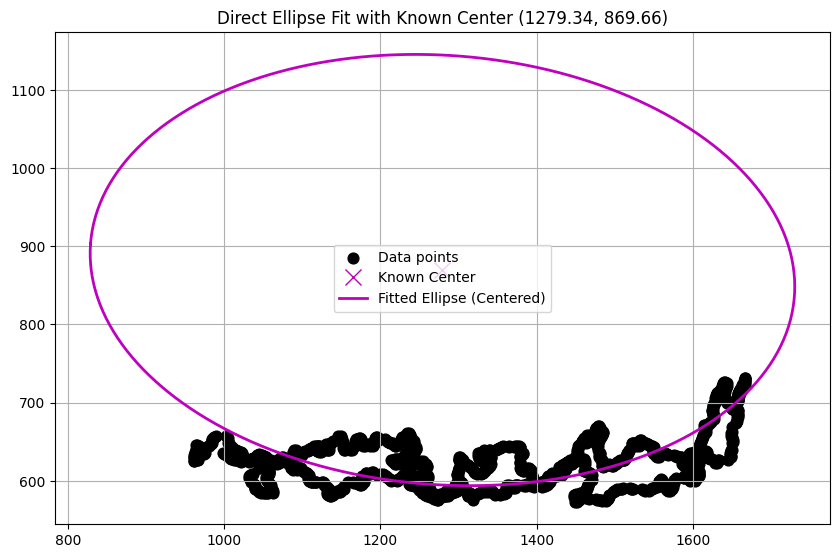

Ellipse:Axes=(451.54, 274.60), Angle=3.07°

Processing output_contour_0.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,25387.7244,36434.3224,52287.4688,1.0000


...

**Final semi-major axis a:** 314.954301

**Final semi-minor axis b:** 37.229394

**Final rotation angle (radians):** 2.398584

**Final rotation angle (degrees):** 137.428752

### Step 6: Visualization

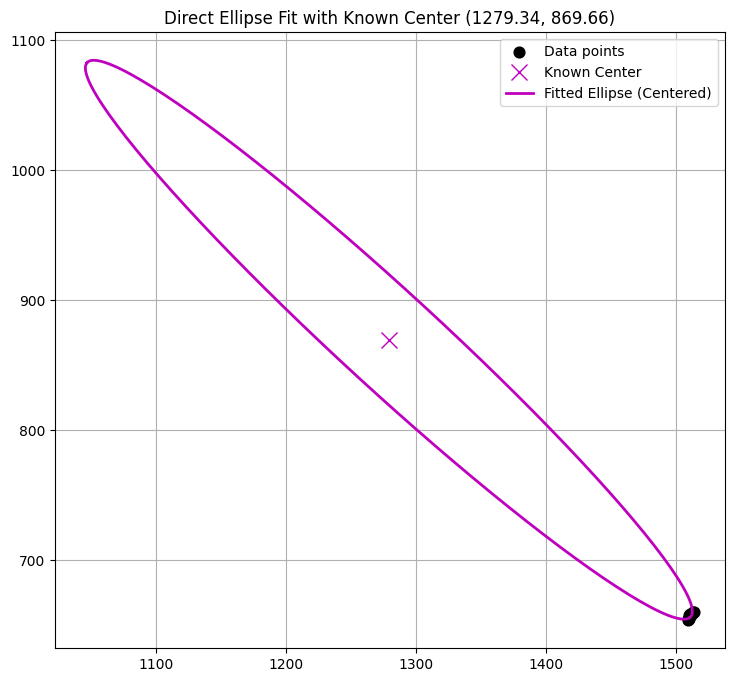

Ellipse:Axes=(314.95, 37.23), Angle=2.40°

Processing output_contour_5.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,1320.2510,8199.5790,50924.4816,1.0000


...

**Final semi-major axis a:** 315.609699

**Final semi-minor axis b:** 167.771419

**Final rotation angle (radians):** -2.514611

**Final rotation angle (degrees):** -144.076578

### Step 6: Visualization

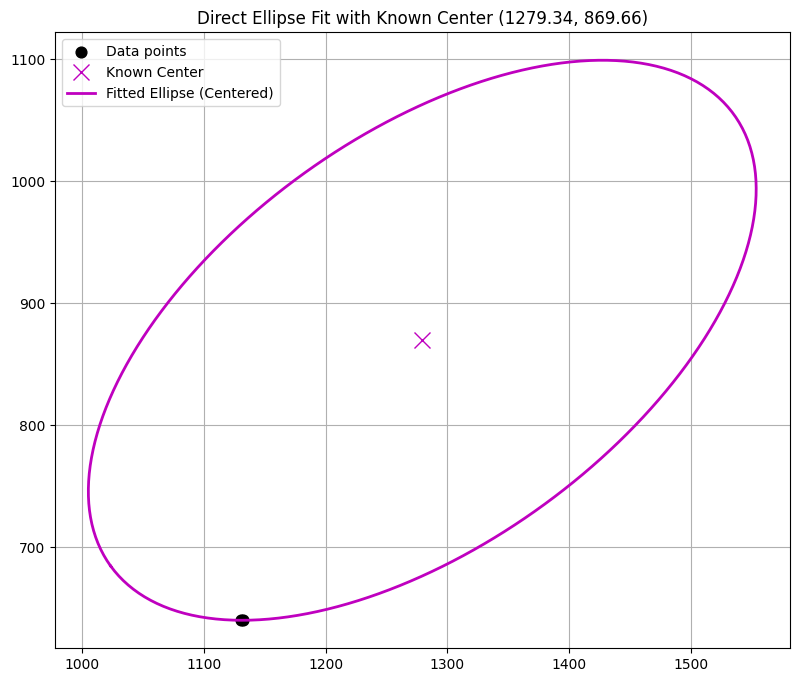

Ellipse:Axes=(315.61, 167.77), Angle=-2.51°

Processing output_contour_18.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,2055.2856,-19010.6815,175842.2336,1.0000


...

**Final semi-major axis a:** 378.708651

**Final semi-minor axis b:** 208.560704

**Final rotation angle (radians):** 2.767707

**Final rotation angle (degrees):** 158.577956

### Step 6: Visualization

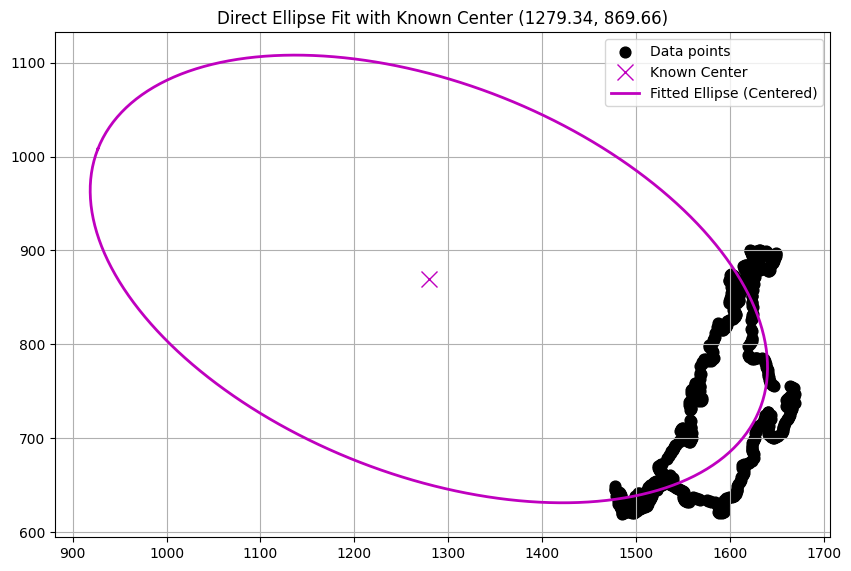

Ellipse:Axes=(378.71, 208.56), Angle=2.77°

Processing output_contour_20.csv
Index(['X', 'Y'], dtype='object')


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,5827.0716,-23994.8789,98806.7856,1.0000
1,6136.4126,-24780.2203,100068.1275,1.0000
2,6294.0831,-25096.5558,100068.1275,1.0000
3,6453.7536,-25493.2265,100701.7984,1.0000
4,6453.7536,-25573.5618,101337.4694,1.0000


...

**Final semi-major axis a:** 436.285414

**Final semi-minor axis b:** 174.772882

**Final rotation angle (radians):** -1.515308

**Final rotation angle (degrees):** -86.820740

### Step 6: Visualization

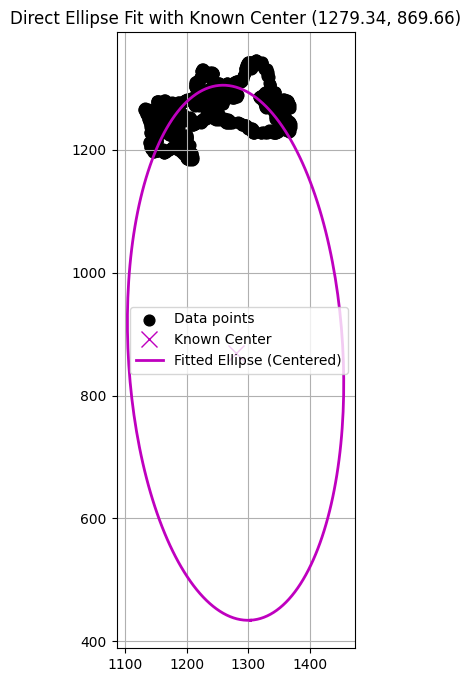

Ellipse:Axes=(436.29, 174.77), Angle=-1.52°


In [262]:
remaining_files = glob.glob('output_contour*.csv')
for file in remaining_files:
    print(f"\nProcessing {file}")
    
    try:
        df = pd.read_csv(file)
    except Exception as e:
        print(f"Could not read {file}: {e}")
        continue
    print(df.columns)

    x = df.iloc[:, 0].values
    y = df.iloc[:, 1].values

    try:
        # coeffs = fit_ellipse(x, y)
        # x0, y0, a_axis, b_axis, angle = ellipse_params(coeffs)
        #a_axis, b_axis, angle = fit_centered_ellipse(x, y, center)
        a_axis, b_axis, angle = fit_ellipse_direct_centered(x,y,center)
    except ValueError as e:
        print(f"Skipping {file}: {e}")
        continue

    print(f"Ellipse:Axes=({a_axis:.2f}, {b_axis:.2f}), Angle={angle:.2f}°")


## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,25387.7244,36434.3224,52287.4688,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 451.538244

**Final semi-minor axis b:** 274.597382

**Final rotation angle (radians):** 3.066976

**Final rotation angle (degrees):** 175.724780

### Step 6: Visualization

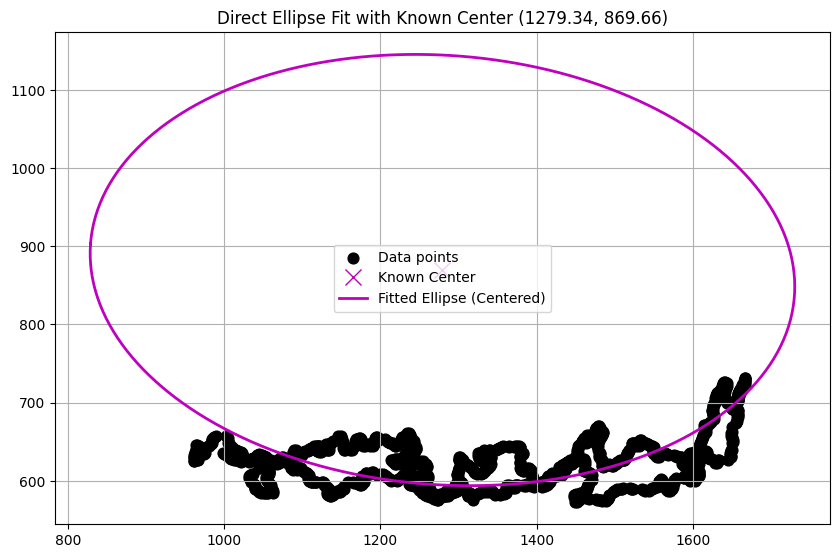

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,44662.5912,62061.6699,86238.8581,1.0000
1,45086.2617,62142.9991,85652.5290,1.0000
2,45511.9322,62435.6637,85652.5290,1.0000
3,45939.6027,62513.9929,85068.2000,1.0000
4,48107.9553,63972.3156,85068.2000,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 416.672129

**Final semi-minor axis b:** 313.221659

**Final rotation angle (radians):** -2.906080

**Final rotation angle (degrees):** -166.506137

### Step 6: Visualization

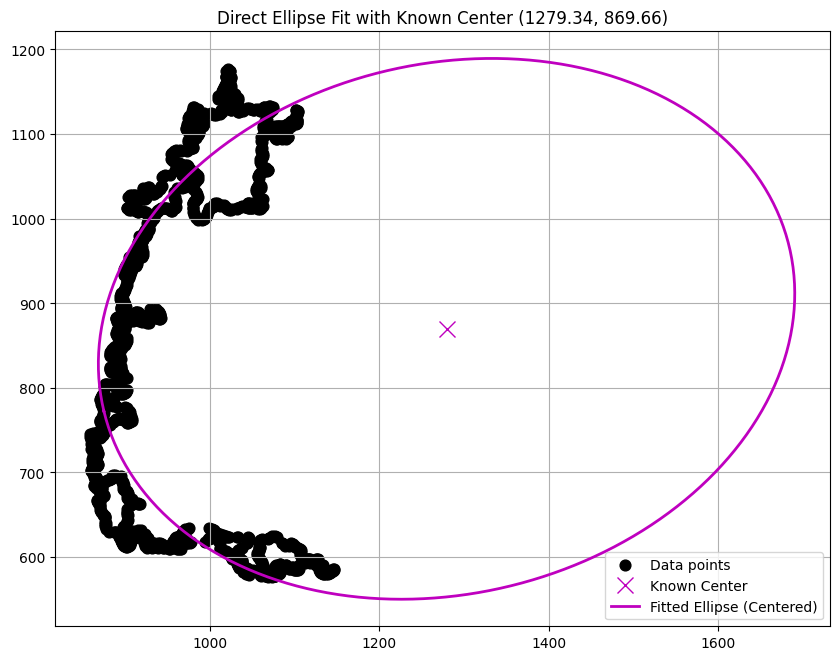

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,18045.9615,-33494.5442,62168.1750,1.0000
1,17778.2910,-33245.2087,62168.1750,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** inf

**Final semi-minor axis b:** 244.335258

**Final rotation angle (radians):** 1.570796

**Final rotation angle (degrees):** 90.000000

### Step 6: Visualization

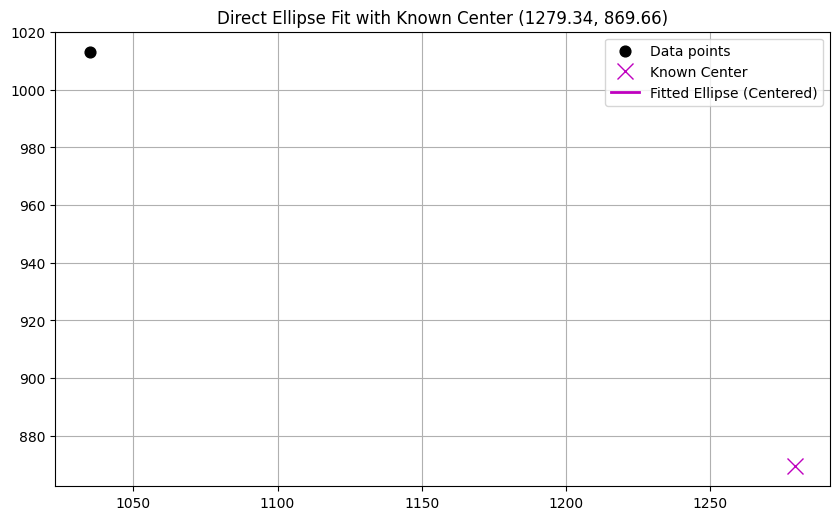

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,141628.2263,-7276.6178,373.8603,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 357.985529

**Final semi-minor axis b:** 279.315559

**Final rotation angle (radians):** -2.799375

**Final rotation angle (degrees):** -160.392377

### Step 6: Visualization

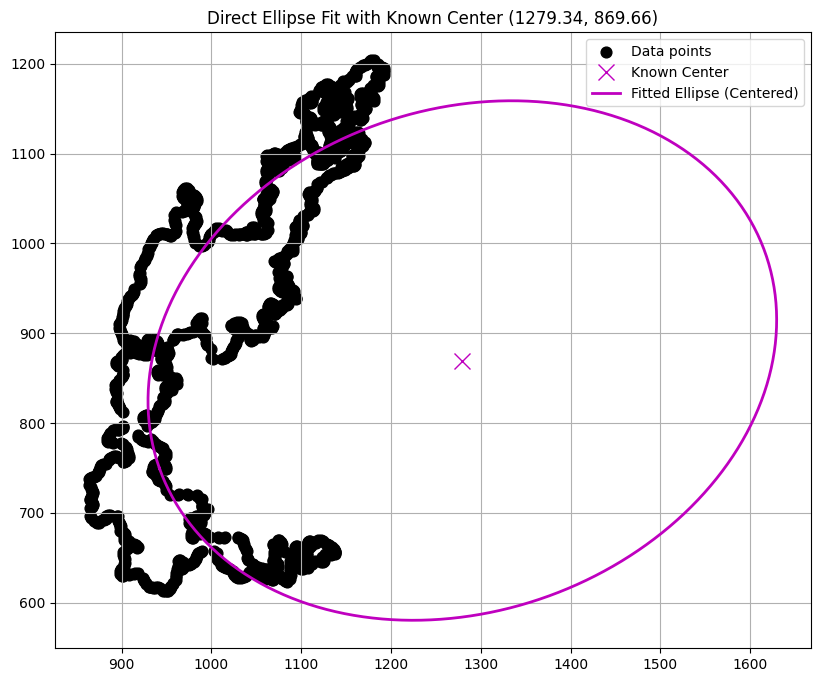

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,94043.2641,71555.7607,54445.4400,1.0000
1,93430.9346,71628.0900,54913.1110,1.0000
2,93430.9346,71933.7548,55382.7819,1.0000
3,91605.9462,72135.7426,56803.7947,1.0000
4,91605.9462,72438.4073,57281.4656,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 432.038465

**Final semi-minor axis b:** 186.276360

**Final rotation angle (radians):** -2.080030

**Final rotation angle (degrees):** -119.176923

### Step 6: Visualization

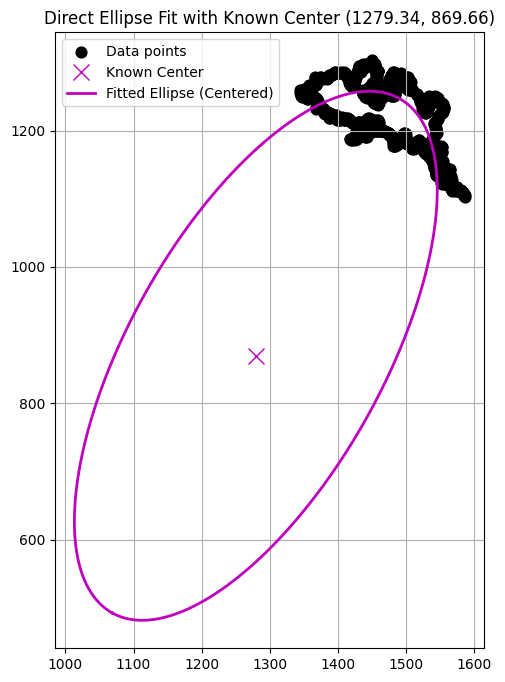

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,2055.2856,-19010.6815,175842.2336,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 436.285414

**Final semi-minor axis b:** 174.772882

**Final rotation angle (radians):** -1.515308

**Final rotation angle (degrees):** -86.820740

### Step 6: Visualization

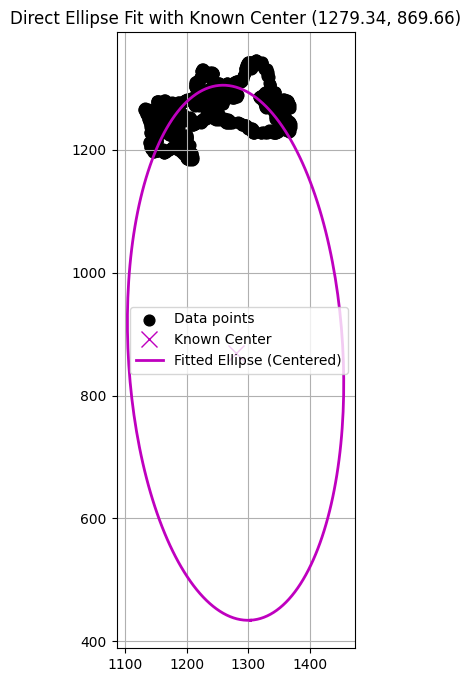

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,42297.9862,-51552.8566,62832.7083,1.0000
1,42297.9862,-51347.1919,62332.3792,1.0000
2,42710.3157,-51390.1917,61834.0501,1.0000
3,42710.3157,-50976.8622,60843.3920,1.0000
4,41887.6567,-50074.2036,59860.7339,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 378.708651

**Final semi-minor axis b:** 208.560704

**Final rotation angle (radians):** 2.767707

**Final rotation angle (degrees):** 158.577956

### Step 6: Visualization

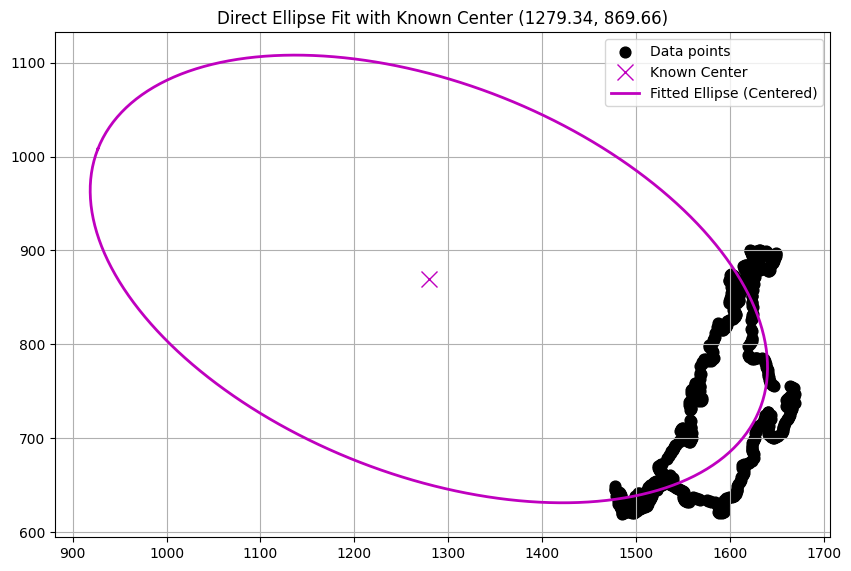

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,29699.4411,32685.8862,35972.6352,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 314.954301

**Final semi-minor axis b:** 37.229394

**Final rotation angle (radians):** 2.398584

**Final rotation angle (degrees):** 137.428752

### Step 6: Visualization

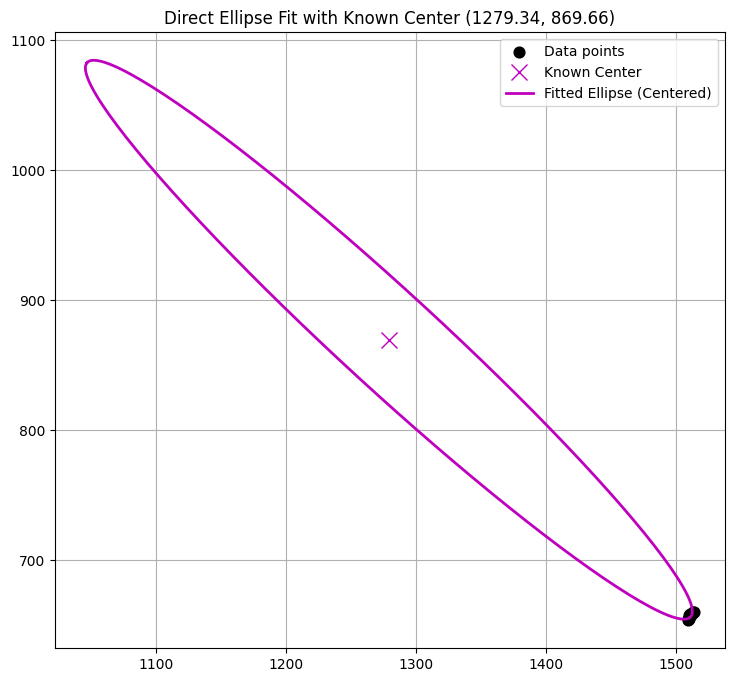

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,1320.2510,8199.5790,50924.4816,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 315.609699

**Final semi-minor axis b:** 167.771419

**Final rotation angle (radians):** -2.514611

**Final rotation angle (degrees):** -144.076578

### Step 6: Visualization

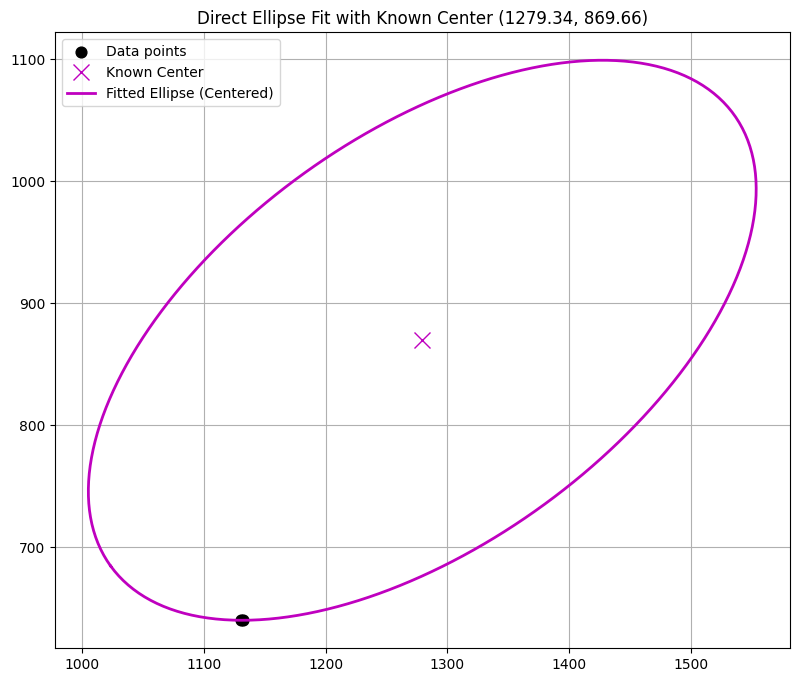

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,1626.9330,9545.9250,56010.1013,1.0000
1,1792.2741,9934.5835,55067.4432,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 291.531943

**Final semi-minor axis b:** 225.923511

**Final rotation angle (radians):** 2.522232

**Final rotation angle (degrees):** 144.513266

### Step 6: Visualization

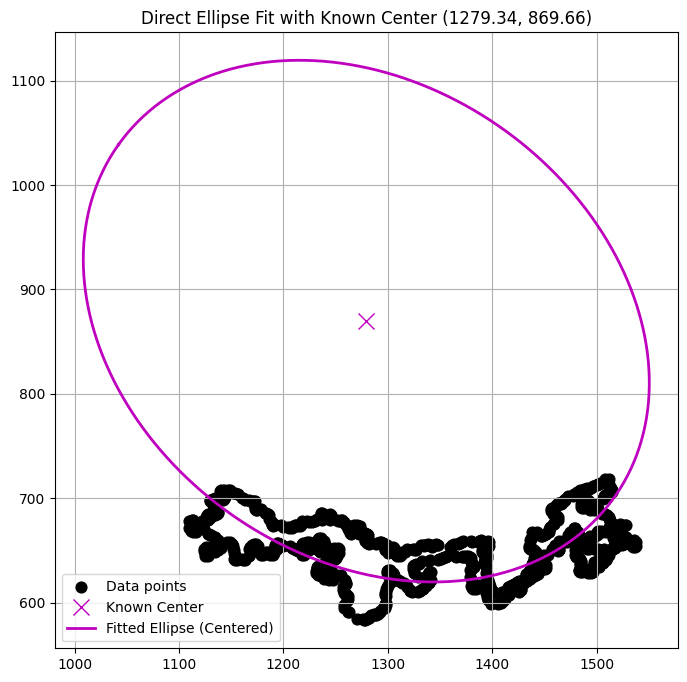

## Direct Ellipse Fitting with Known Center [1279.3352578   869.66453329]

### Step 2: Build reduced design matrix D' and scatter matrix S'

**Design matrix D' (first 5 rows):**

,0,1,2,3
0,47234.6143,50348.8711,53668.4560,1.0000
1,47670.2848,50362.2003,53206.1269,1.0000
2,49432.9669,51284.8585,53206.1269,1.0000
3,49878.6374,51292.1878,52745.7979,1.0000
4,51227.6489,51981.1814,52745.7979,1.0000


**Scatter matrix S':**

...

**Final semi-major axis a:** 335.492648

**Final semi-minor axis b:** 154.417156

**Final rotation angle (radians):** -2.781674

**Final rotation angle (degrees):** -159.378191

### Step 6: Visualization

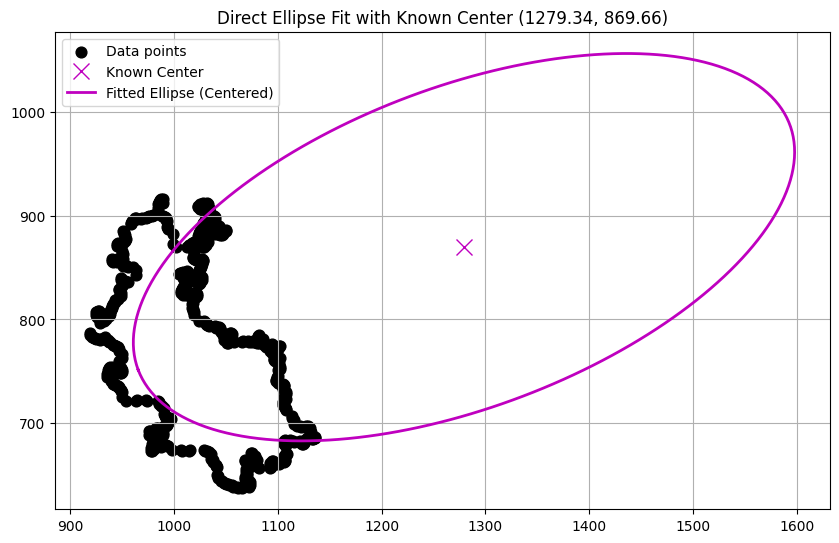

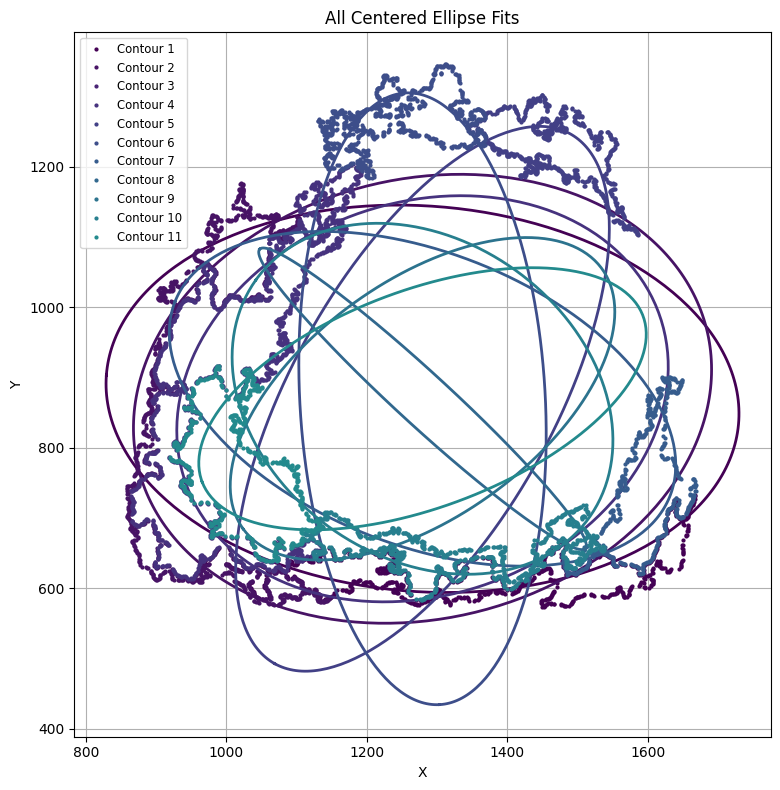

In [264]:
all_data = []
all_ellipses = []

# Sort files to maintain consistent color order
remaining_files = sorted(glob.glob('output_contour*.csv'))
colors = plt.cm.viridis(np.linspace(0, 1, len(remaining_files)))

for i, file in enumerate(remaining_files):
    try:
        df = pd.read_csv(file)
        x = df.iloc[:, 0].values
        y = df.iloc[:, 1].values
        a_axis, b_axis, angle = fit_ellipse_direct_centered(x, y, center)
        # coeffs = fit_ellipse(x, y)
        # x0, y0, a_axis, b_axis, angle = ellipse_params(coeffs)
        # center = x0,y0

        all_data.append((x, y))
        all_ellipses.append((a_axis, b_axis, angle))

    except Exception as e:
        print(f"Skipping {file}: {e}")
        continue

# Now make one global plot
plt.figure(figsize=(8, 8))

for i, ((x, y), (a_axis, b_axis, angle)) in enumerate(zip(all_data, all_ellipses)):
    color = colors[i]
    plt.plot(x, y, 'o', markersize=2, label=f'Contour {i+1}', color=color)

    theta = np.linspace(0, 2*np.pi, 300)
    angle_rad = angle
    ellipse_x = center[0] + a_axis * np.cos(theta) * np.cos(angle_rad) - b_axis * np.sin(theta) * np.sin(angle_rad)
    ellipse_y = center[1] + a_axis * np.cos(theta) * np.sin(angle_rad) + b_axis * np.sin(theta) * np.cos(angle_rad)
    plt.plot(ellipse_x, ellipse_y, '-', linewidth=2, color=color)

plt.gca().set_aspect('equal')
plt.title("All Centered Ellipse Fits")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()
